# Croston’s Method for Intermittent Demand with `numpyro_forecast`

This notebook ports the blog post [**Croston’s Method for Intermittent
Time Series Forecasting in
NumPyro**](https://juanitorduz.github.io/croston_numpyro/) to the
[`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast)
package. **Intermittent demand** series are dominated by zeros: most
periods see no demand at all, and the occasional non-zero observation
arrives at irregular times. Spare parts, slow-moving retail items, and
rarely ordered SKUs all look like this. Classical smoothing methods
degrade badly on such data, because averaging over the zeros drags the
forecast toward zero while telling us nothing about *when* the next
demand will arrive or *how large* it will be.

[Croston’s
method](https://www.pmorgan.com.au/tutorials/crostons-method/) attacks
the problem by splitting the series $y_t$ into two better-behaved
components: the **demand sizes** $z_t$ (the non-zero values) and the
**demand intervals** $p_t$ (the number of periods between consecutive
non-zero values). Each component is smoothed separately with simple
exponential smoothing, and the forecast is their ratio,

$$\hat{y}_{t+h} = \frac{\hat{z}_t}{\hat{p}_t},$$

which reads as the expected demand *per period*: how much arrives,
divided by how often. The classical method uses one shared smoothing
parameter; the “Croston optimized” variant (as implemented, for example,
by
[statsforecast](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#crostonoptimized))
estimates a separate smoothing parameter for each component, typically
restricted to a range like $[0.1, 0.3]$, since values near $1$ make the
forecast jump reactively after every demand. We follow the blog post and
build a **Bayesian** version of the optimized variant, where the
smoothing parameters, initial levels, and noise scales all get priors
and posteriors, so the forecast comes with genuine uncertainty bands
instead of the symmetric conformal intervals of the classical
implementations (which can happily cover negative demand).

Two practical notes on the port, in the same spirit as the [ARMA
example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html):

- The blog post models the two *derived* series directly, each with the
  level model from [its exponential smoothing
  predecessor](https://juanitorduz.github.io/exponential_smoothing_numpyro/)
  (the [exponential smoothing
  example](https://juanitorduz.github.io/numpyro_forecast/examples/exponential_smoothing_state_space.html)
  in this documentation treats the richer state space variant of the
  same idea). Here we implement the *same* likelihood on the **raw
  calendar timeline**: one `jax.lax.scan` runs both level recursions,
  frozen outside demand events by `jnp.where`, and the likelihood terms
  are **masked** so that only demand events contribute. The two
  formulations are mathematically identical, but the calendar-time
  version plugs straight into the package’s machinery: `fit_mcmc`,
  `to_datatree`, and, crucially, `backtest`, which slices calendar time
  when it moves the train/test split forward.
- As in the ARMA example, the observed series itself plays the role of
  the covariates, because the model needs the demand history (values
  *and* timing) to run its recursions, and the `covariates` argument is
  the carrier that spans the full horizon at prediction time. The model
  only ever reads the first `t_obs` rows, so no future information leaks
  into a forecast.

## Prepare notebook

In [1]:
from functools import partial

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import preliz as pz
import xarray as xr
from jax import random
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from numpyro.handlers import scope
from numpyro.infer import Predictive

from numpyro_forecast import (
    HMCForecaster,
    backtest,
    eval_coverage,
    eval_crps,
    forecasting_model,
    predictions_to_datatree,
    to_datatree,
)
from numpyro_forecast.functional import Horizon, fit_mcmc
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")

## Generate data

As in the blog post, we simulate $T = 80$ periods of intermittent demand
by drawing counts from a Poisson distribution with a small rate,
$y_t \sim \text{Poisson}(0.3)$, so roughly three quarters of the periods
are zero and the non-zero demands are small counts. We hold out the last
$15\%$ of the series as a test window for the fixed-origin forecast (the
rolling-origin evaluation at the end refits over this window step by
step).

In [2]:
n = 80
lam = 0.3

rng_key, rng_subkey = random.split(rng_key)
y = random.poisson(key=rng_subkey, lam=lam, shape=(n,)).astype(jnp.float32)
t = np.arange(n)

n_train = round(0.85 * n)
n_test = n - n_train
y_train, y_test = y[:n_train], y[n_train:]
t_train, t_test = t[:n_train], t[n_train:]

print(f"total: {n}, train: {n_train}, test: {n_test}")
print(f"share of zero periods: {float(jnp.mean(y == 0)):.2f}")

total: 80, train: 68, test: 12
share of zero periods: 0.73

Throughout the package, time lives at axis `-2` and the observation
dimension at axis `-1`. Following the design note above, the training
series also serves as the covariates; for the fixed-origin forecast we
extend the covariates over the horizon with zeros, which is leak-free
because the model never reads past `t_obs`.

train data shape: (68, 1), full covariates shape: (80, 1)

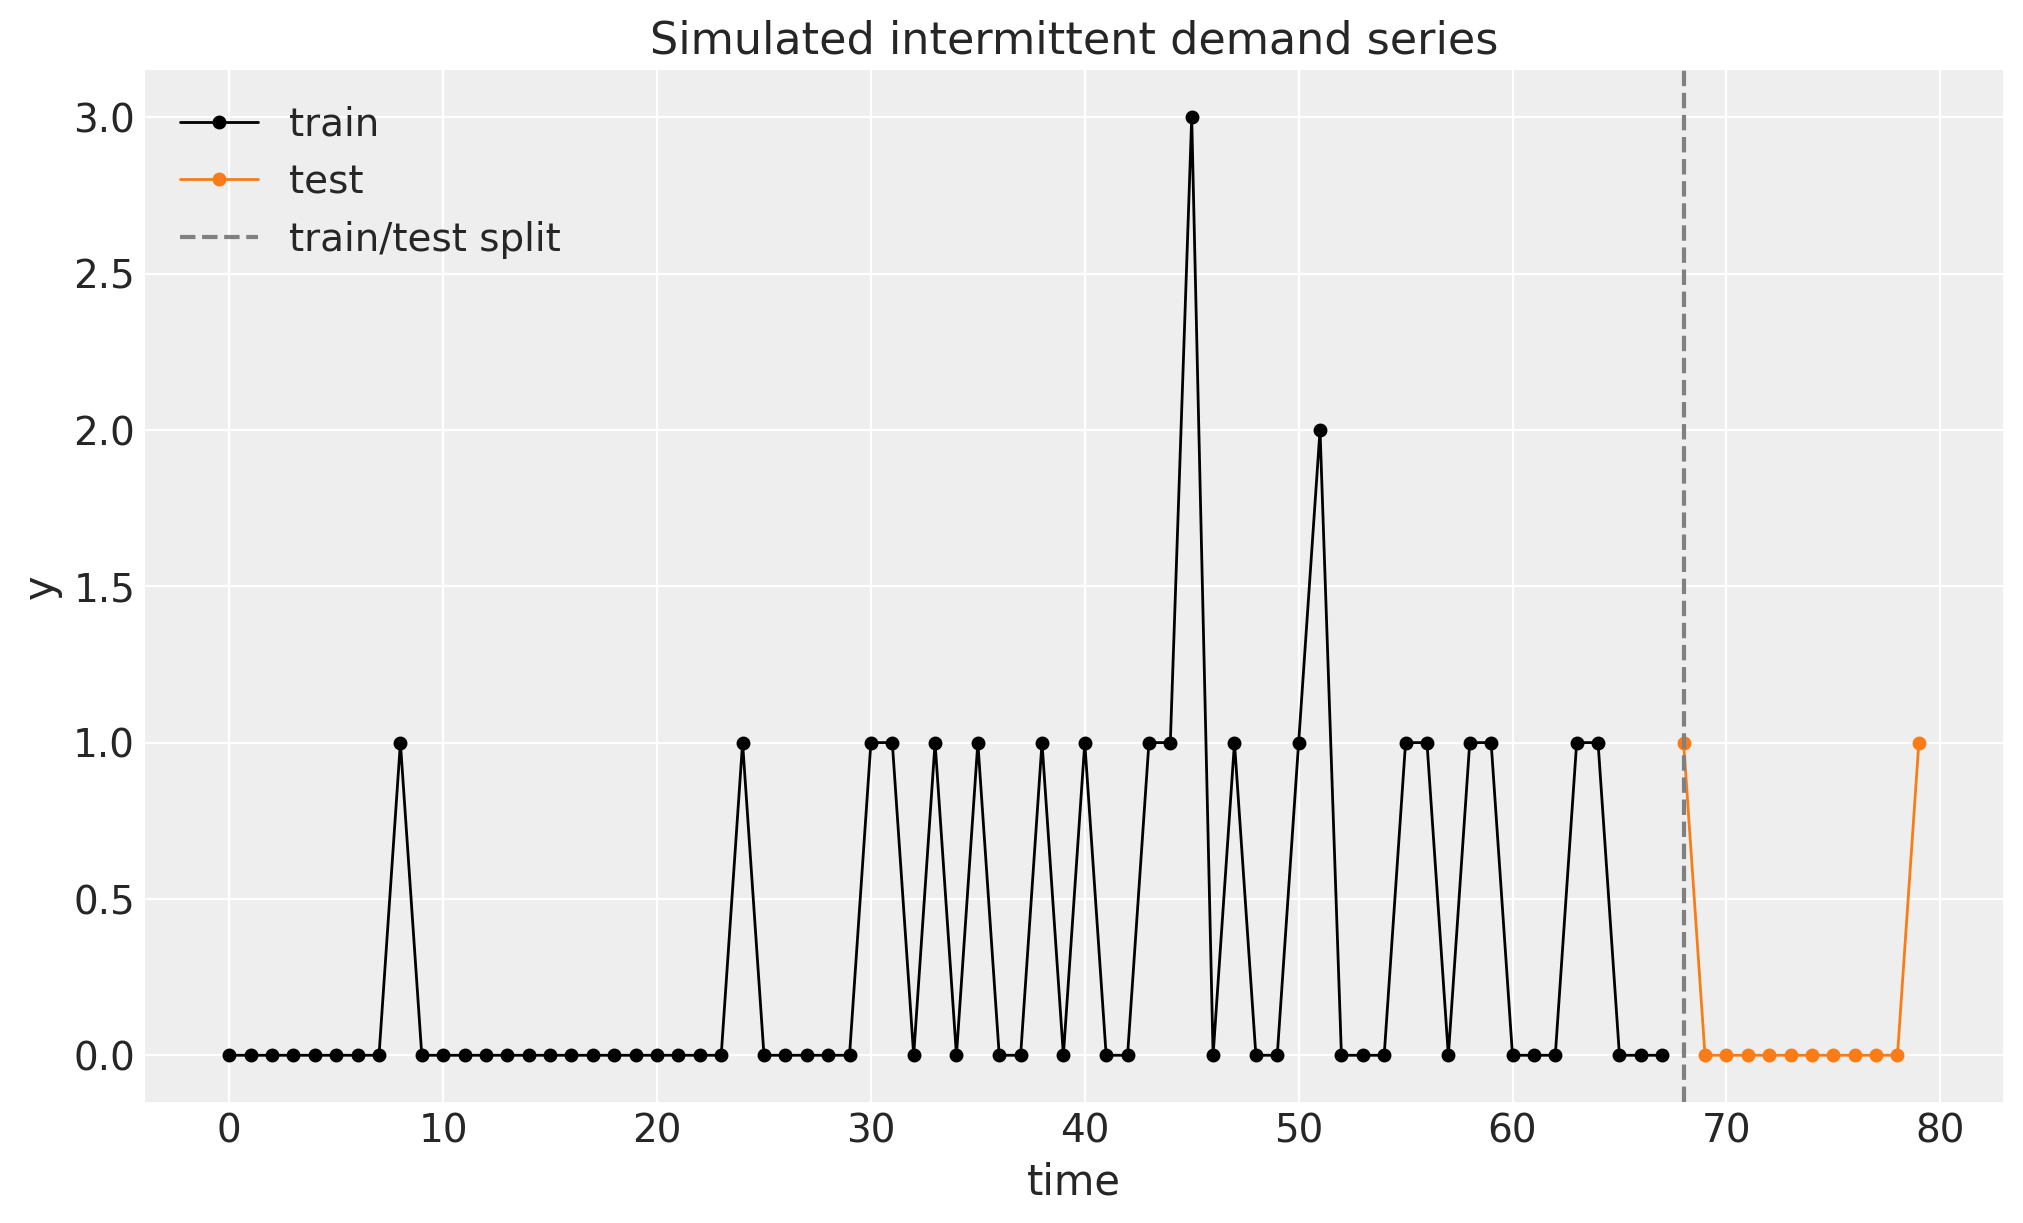

In [3]:
train_data = y_train[:, None]
test_data = y_test[:, None]
data_full = y[:, None]  # full series, used by the cross-validation at the end
covariates_train = train_data  # the demand history is the "covariate" of a Croston model
covariates_full = jnp.concatenate([y_train, jnp.zeros(n_test)])[:, None]
print(f"train data shape: {train_data.shape}, full covariates shape: {covariates_full.shape}")

fig, ax = plt.subplots()
ax.plot(t_train, y_train, "o-", color="black", lw=1, ms=4, label="train")
ax.plot(t_test, y_test, "o-", color="C1", lw=1, ms=4, label="test")
ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated intermittent demand series", xlabel="time", ylabel="y");

## Demand sizes and intervals

To see the raw material Croston’s method works with, we derive the two
component series from the training window: the demand sizes $z$ are the
non-zero values in order of appearance, and the intervals $p$ are the
gaps between consecutive demand times. Following the blog post’s
convention (`jnp.diff` with `prepend=-1`), the first interval counts
from just before the start of the series, so a first demand at index $i$
has interval $i + 1$. Note that both series live on the *event* axis
(one entry per demand event, not per period) and are much shorter than
the original series.

The model below never uses these arrays directly: it recomputes the same
information on the calendar axis inside the model body, which is what
lets the cross-validation slice calendar time. This cell is exposition
only.

demand events in train: 20 of 68 periods
demand sizes z: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 3. 1. 1. 2. 1. 1. 1. 1. 1. 1.]
demand intervals p: [ 9. 16.  6.  1.  2.  2.  3.  2.  3.  1.  1.  2.  3.  1.  4.  1.  2.  1.
  4.  1.]

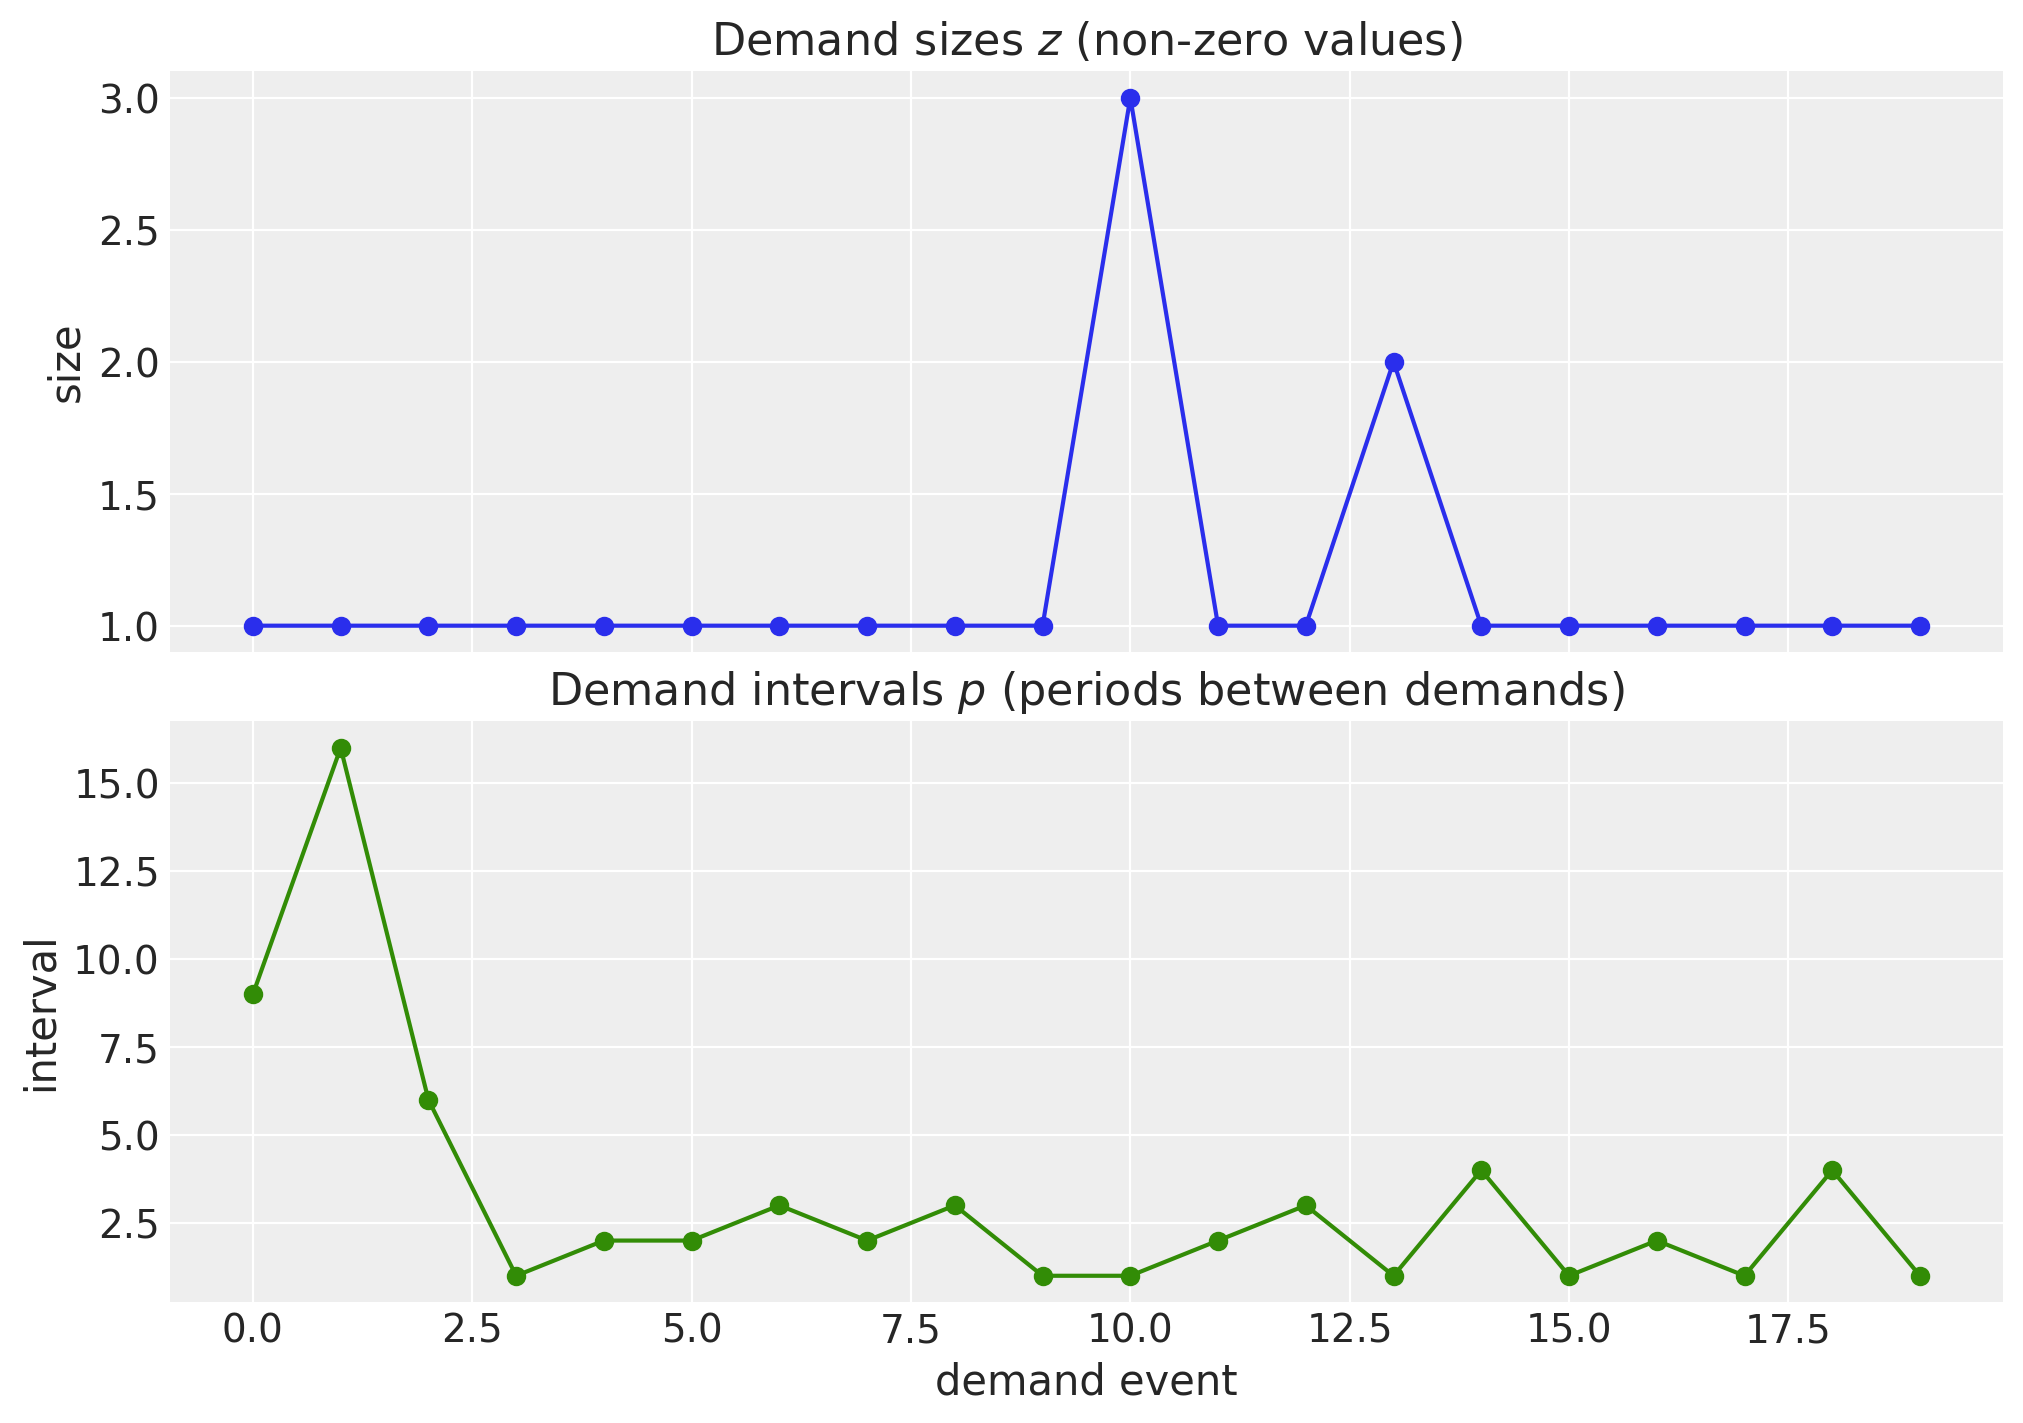

In [4]:
z = y_train[y_train != 0]
p_idx = jnp.flatnonzero(y_train)
p = jnp.diff(p_idx, prepend=-1).astype(jnp.float32)

print(f"demand events in train: {z.size} of {n_train} periods")
print(f"demand sizes z: {np.asarray(z)}")
print(f"demand intervals p: {np.asarray(p)}")

fig, (ax_z, ax_p) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 7), sharex=True, layout="constrained"
)
ax_z.plot(np.arange(z.size), np.asarray(z), "o-", color="C0")
ax_z.set(title="Demand sizes $z$ (non-zero values)", ylabel="size")
ax_p.plot(np.arange(p.size), np.asarray(p), "o-", color="C2")
ax_p.set(
    title="Demand intervals $p$ (periods between demands)",
    xlabel="demand event",
    ylabel="interval",
);

## Prior for the smoothing parameters

Both components get a $\text{Beta}(2, 20)$ prior on their smoothing
parameter. Its mean is $2/22 \approx 0.09$ and most of its mass sits
below $0.3$, consistent with the standard practice for Croston’s method:
the classical optimized implementations restrict the smoothing parameter
to roughly $[0.1, 0.3]$, because a level that reacts strongly to each
new demand produces volatile, over-reactive forecasts on sparse data.
The prior concentrates on the same low-smoothing region while also
keeping mass near zero, letting the data decide within it.

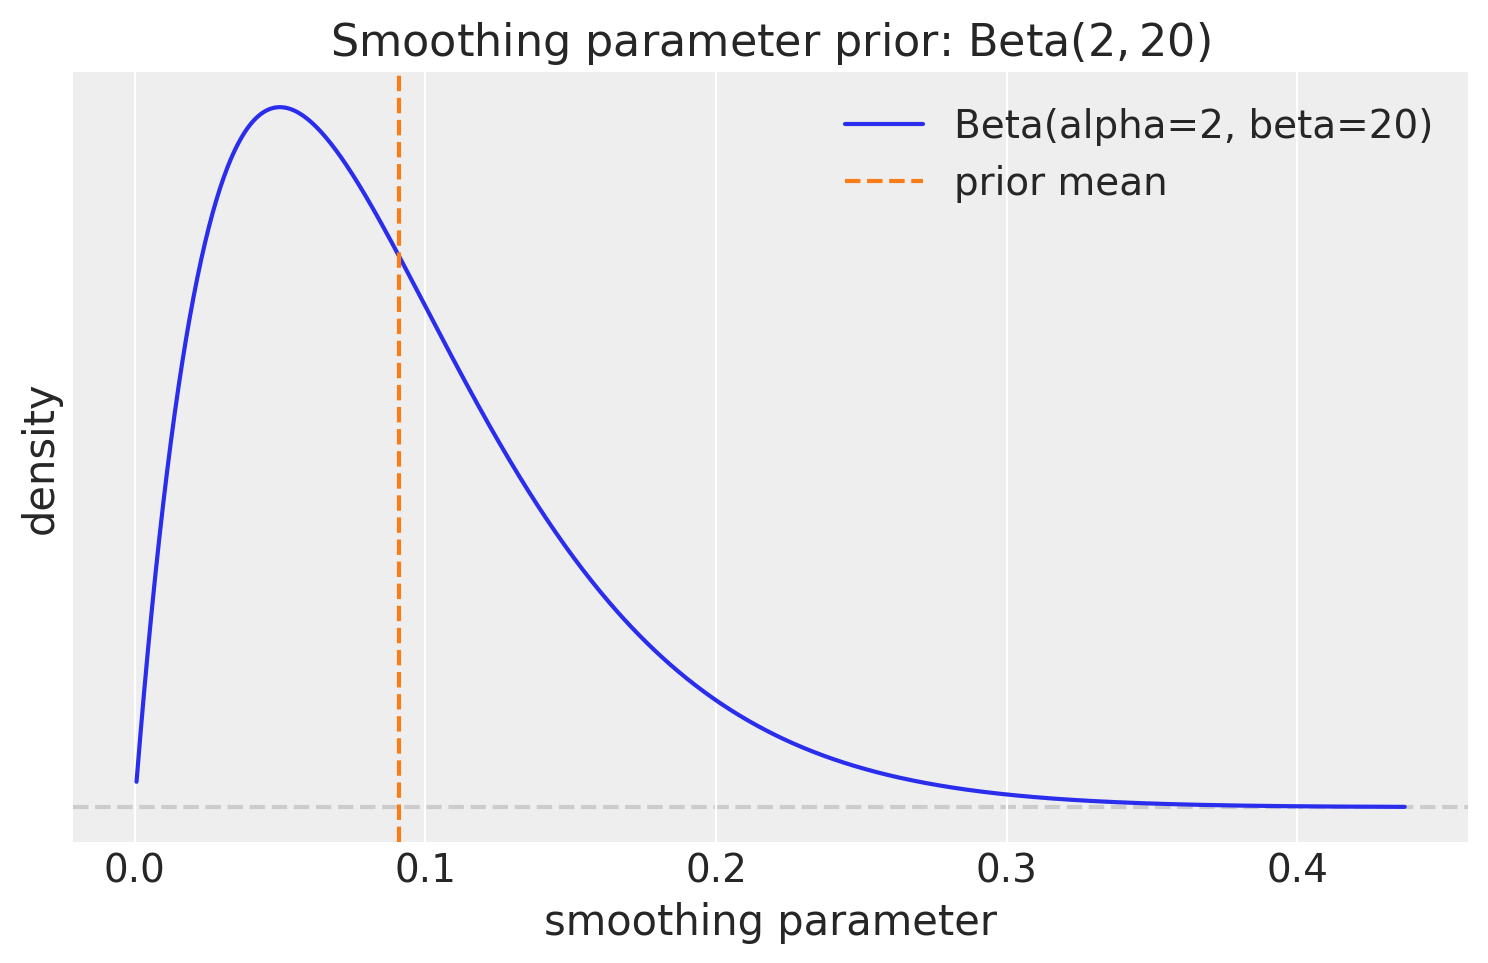

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
pz.Beta(2, 20).plot_pdf(ax=ax, color="C0")
ax.axvline(2 / 22, color="C1", ls="--", label="prior mean")
ax.legend()
ax.set(
    title=r"Smoothing parameter prior: $\text{Beta}(2, 20)$",
    xlabel="smoothing parameter",
    ylabel="density",
);

## Model specification

Croston’s method runs **simple exponential smoothing** on each
component. Writing $\ell_t$ for a component’s level and $x_t$ for its
observed value at a demand event, the level updates only when a demand
occurs,

$$
\ell_t =
\begin{cases}
\alpha \, x_t + (1 - \alpha) \, \ell_{t-1} & \text{if } y_t > 0, \\
\ell_{t-1} & \text{otherwise},
\end{cases}
$$

and the likelihood at each demand event is the one-step-ahead prediction
of the level model, $x_t \sim \text{Normal}(\ell_{t-1}, \sigma)$,
exactly the level model of the blog’s [exponential smoothing
notes](https://juanitorduz.github.io/exponential_smoothing_numpyro/). We
run two such recursions side by side: one for the demand sizes
($x_t = y_t$ at demand events) and one for the **inverse** intervals
($x_t = 1/p_t$). Modeling $1/p$ instead of $p$ is the blog post’s
numerical stability trick: the forecast then becomes a *product* of
posterior samples, $\hat{y} = \hat{z} \cdot \widehat{1/p}$, instead of a
quotient by samples that can sit close to zero.

The trick has a statistical cost worth naming. Smoothing $1/p$ estimates
$\mathrm{E}[1/p]$, and by Jensen’s inequality
$\mathrm{E}[1/p] > 1/\mathrm{E}[p]$ whenever the intervals vary, so the
fitted rate is biased *upward* relative to the true demand per period
$\mathrm{E}[z]/\mathrm{E}[p]$. This is not specific to our Bayesian
variant: the classical ratio $\hat{z}_t/\hat{p}_t$ suffers a related
upward bias, analyzed by Syntetos and Boylan (2005), whose
$(1 - \alpha/2)$ correction factor (the “SBA” estimator) is the standard
remedy. We quantify the effect on our forecast below.

Each component gets its own priors,

One transparency note on the priors: $\text{Normal}(0, 1)$ on the
initial levels allows negative values for two quantities that are
strictly positive (a demand size and an inverse interval). We keep the
blog post’s choice for comparability; centering the inits on the data or
switching to positive priors is the natural refinement, in the same
spirit as the truncated or log-normal component likelihoods mentioned in
the forecast section.

Since both components run the *same* level model, we write it once and
compose, exactly as the blog post does: there `croston_model` is built
from two `level_model` calls wrapped in NumPyro’s
[`scope`](https://num.pyro.ai/en/stable/handlers.html#scope) handler,
which prepends a prefix to every sample site inside the wrapped function
so the two copies get distinct parameter names. We mirror that structure
on the calendar axis. The reusable `level_model` samples the three
component priors (sites `smoothing`, `init`, and `noise`), runs the
where-gated level recursion with a `jax.lax.scan` that emits the
*pre-update* levels (the one-step-ahead means), and, when forecasting,
draws the component’s flat predictive at a site named `future` from
$\text{Normal}(\ell_T, \sigma)$, the level model’s forecast distribution
given the final level. Calling it under
`scope(level_model, "z", divider="_")` and
`scope(level_model, "p_inv", divider="_")` yields the parameter names
`z_smoothing`, `z_init`, …, `p_inv_future`.

The `croston` body then only does what is specific to Croston’s method,
following the package’s conventions for a custom model (see the ARMA
example for the pattern):

1.  **Bookkeeping.** From the observed prefix of the covariates it
    computes the demand indicator and, with a cumulative maximum over
    the last-seen demand index, the interval since the previous demand
    at every period. Both are fixed-shape computations, so they compile
    under `jax.lax.scan` and NUTS.
2.  **In sample.** The likelihood is registered as two **masked**
    observation sites built from the level models’ one-step-ahead means,
    so only demand events contribute (masked periods add exactly zero
    log-density and zero gradient): the site `"obs"` carries the
    demand-size likelihood against the raw series, and `"obs_intervals"`
    the inverse-interval likelihood. The deterministic site `"rate"`
    exposes the running Croston fitted rate
    $\ell^z_{t-1} \cdot \ell^{1/p}_{t-1}$ for the in-sample plot.
3.  **Out of sample.** When `h.future > 0` the two scoped level models
    draw their predictives at the `"z_future"` and `"p_inv_future"`
    sites, and the body exposes their product as the `"forecast"` site
    the forecaster reads. Because these sites do not exist while
    training, `Predictive` draws them from the prior at forecast time,
    the package’s standard `_future` pattern. Croston’s forecast is
    *flat* by construction: without new observations the levels never
    move, so every horizon step has the same predictive distribution.

In [6]:
def level_model(values: Array, is_event: Array, future: int) -> tuple[Array, Array, Array | None]:
    """Masked simple exponential smoothing level model on the calendar axis.

    Samples the component priors (sites ``smoothing``, ``init``, ``noise``), runs
    the where-gated level recursion, and, when ``future > 0``, draws the flat
    forecast predictive at the site ``future``. Meant to be called under
    :func:`numpyro.handlers.scope`, which prefixes the site names per component.

    Parameters
    ----------
    values
        Observed component values on the calendar axis; read only where
        ``is_event`` is true.
    is_event
        Boolean demand indicator on the calendar axis; the level only updates
        where it is true.
    future
        Number of forecast steps (``0`` while training).

    Returns
    -------
    tuple[Array, Array, Array | None]
        The one-step-ahead means (the pre-update levels), the observation noise
        scale, and the forecast predictive draws (``None`` when ``future == 0``).
    """
    smoothing = numpyro.sample("smoothing", dist.Beta(concentration1=2, concentration0=20))
    init = numpyro.sample("init", dist.Normal(loc=0, scale=1))
    # jnp.asarray only narrows numpyro's union return type for the type checker.
    noise = jnp.asarray(numpyro.sample("noise", dist.HalfNormal(scale=1)))

    def transition_fn(carry, inputs):
        x_t, event_t = inputs
        level = jnp.where(event_t, smoothing * x_t + (1 - smoothing) * carry, carry)
        # Emit the pre-update level: the one-step-ahead mean.
        return level, carry

    last_level, mu = jax.lax.scan(transition_fn, init, (values, is_event))

    future_draws = None
    if future > 0:
        # jnp.asarray only narrows numpyro's union return type for the type checker.
        future_draws = jnp.asarray(
            numpyro.sample(
                "future", dist.Normal(loc=last_level, scale=noise).expand([future]).to_event(1)
            )
        )
    return mu, noise, future_draws


def croston(h: Horizon, covariates: Array) -> None:
    """Croston's method as two scoped masked exponential smoothing level models.

    Parameters
    ----------
    h
        The train/forecast horizon for the current model call.
    covariates
        The observed demand series itself, with time at axis ``-2``; only the
        first ``h.t_obs`` rows are read.
    """
    y_obs = covariates[..., : h.t_obs, 0]  # observed history only; never reads beyond t_obs
    is_demand = y_obs > 0

    # Interval since the previous demand at every period: cumulative max of the
    # last-seen demand index, shifted one step so it is strictly "before t".
    idx = jnp.arange(h.t_obs)
    last_at_or_before = jax.lax.cummax(jnp.where(is_demand, idx, -1), axis=0)
    last_before = jnp.concatenate([jnp.array([-1]), last_at_or_before[:-1]])
    p_inv_obs = 1.0 / (idx - last_before).astype(y_obs.dtype)

    z_mu, z_noise, z_future = scope(level_model, "z", divider="_")(y_obs, is_demand, h.future)
    p_inv_mu, p_inv_noise, p_inv_future = scope(level_model, "p_inv", divider="_")(
        p_inv_obs, is_demand, h.future
    )

    numpyro.deterministic("rate", (z_mu * p_inv_mu)[:, None])
    numpyro.sample(
        "obs",
        dist.Normal(loc=z_mu[:, None], scale=z_noise).mask(is_demand[:, None]),
        obs=h.data,
    )
    numpyro.sample(
        "obs_intervals",
        dist.Normal(loc=p_inv_mu[:, None], scale=p_inv_noise).mask(is_demand[:, None]),
        obs=p_inv_obs[:, None],
    )

    if z_future is not None and p_inv_future is not None:  # exactly when h.future > 0
        numpyro.deterministic("z_forecast", z_future[:, None])
        numpyro.deterministic("p_inv_forecast", p_inv_future[:, None])
        numpyro.deterministic("forecast", (z_future * p_inv_future)[:, None])


model = forecasting_model(croston)

## Inference with NUTS

We fit the model on the training window with the No-U-Turn Sampler
through the functional
[`fit_mcmc`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.mcmc.fit_mcmc.html),
running $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps
each. The posterior has just six scalar parameters, three per component.

We then export the fit into an ArviZ-schema `xarray.DataTree` with
[`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html).
Because we pass the *extended* covariates, which reach `n_test` steps
past the data, the tree automatically carries `predictions` groups with
the out-of-sample forecast draws next to the posterior, the in-sample
posterior predictive, and the observed data.

In [7]:
rng_key, rng_subkey = random.split(rng_key)
fit = fit_mcmc(
    rng_subkey,
    model,
    train_data,
    covariates_train,
    num_warmup=1_000,
    num_samples=1_000,
    num_chains=4,
)

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    fit,
    model,
    train_data,
    covariates_full,
    posterior_dims={"rate": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│ Attributes:
│ inference_library: numpyro
│ creation_library: numpyro_forecast
│ sample_dims: ['chain', 'draw']
├── Group: /posterior
│ Dimensions: (chain: 4, draw: 1000, time: 68, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│ * time (time) int64 544B 0 1 2 3 4 5 6 7 ... 61 62 63 64 65 66 67
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ p_inv_init (chain, draw) float32 16kB 0.3968 0.5238 ... 0.6935 0.1668
│ p_inv_noise (chain, draw) float32 16kB 0.3601 0.3621 ... 0.455 0.4824
│ p_inv_smoothing (chain, draw) float32 16kB 0.03843 0.07998 ... 0.1539
│ rate (chain, draw, time, obs_dim) float32 1MB 0.3456 ... 0.7844
│ z_init (chain, draw) float32 16kB 0.8709 1.202 ... 1.126 1.271
│ z_noise (chain, draw) float32 16kB 0.431 0.6101 ... 0.5139 0.6101
│ z_smoothing (chain, draw) float32 16kB 0.0827 0.04026 ... 0.04315
│ Attributes:
│ created_at: 2026-07-17T12:37:45.285863+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.2.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /posterior_predictive
│ Dimensions: (chain: 4, draw: 1000, time: 68, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 544B 0 1 2 3 4 5 6 7 8 ... 59 60 61 62 63 64 65 66 67
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 1MB 1.412 0.3509 ... -0.1541
│ Attributes:
│ created_at: 2026-07-17T12:37:45.476929+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.2.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /observed_data
│ Dimensions: (time: 68, obs_dim: 1)
│ Coordinates:
│ * time (time) int64 544B 0 1 2 3 4 5 6 7 8 ... 59 60 61 62 63 64 65 66 67
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (time, obs_dim) float32 272B 0.0 0.0 0.0 0.0 ... 1.0 0.0 0.0 0.0
│ Attributes:
│ created_at: 2026-07-17T12:37:45.477184+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.2.0
│ creation_library_language: Python
│ sample_dims: []
├── Group: /constant_data
│ Dimensions: (time: 68, covariate_dim: 1)
│ Coordinates:
│ * time (time) int64 544B 0 1 2 3 4 5 6 7 ... 60 61 62 63 64 65 66 67
│ * covariate_dim (covariate_dim) int64 8B 0
│ Data variables:
│ covariates (time, covariate_dim) float32 272B 0.0 0.0 0.0 ... 0.0 0.0
│ Attributes:
│ created_at: 2026-07-17T12:37:45.477359+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.2.0
│ creation_library_language: Python
│ sample_dims: []
├── Group: /predictions
│ Dimensions: (chain: 4, draw: 1000, time: 12, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 96B 68 69 70 71 72 73 74 75 76 77 78 79
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 192kB 0.6731 ... -0.5101
│ Attributes:
│ created_at: 2026-07-17T12:37:46.027046+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.2.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
└── Group: /predictions_constant_data
 Dimensions: (time: 12, covariate_dim: 1)
 Coordinates:
 * time (time) int64 96B 68 69 70 71 72 73 74 75 76 77 78 79
 * covariate_dim (covariate_dim) int64 8B 0
 Data variables:
 covariates (time, covariate_dim) float32 48B 0.0 0.0 0.0 ... 0.0 0.0 0.0
 Attributes:
 created_at: 2026-07-17T12:37:46.027284+00:00
 creation_library: ArviZ
 creation_library_version: 1.2.0
 creation_library_language: Python
 sample_dims: [] xarray.DataTree /posterior (16) Dimensions: chain : 4 draw : 1000 time : 68 obs_dim : 1 Coordinates: (4) chain (chain) int64 0 1 2 3 array([0, 1, 2, 3]) draw (draw) int64 0 1 2 3 4 5 ... 995 996 997 998 999 array([ 0, 1, 2, ..., 997, 998, 999], shape=(1000,)) time (time) int64 0 1 2 3 4 5 6 ... 62 63 64 65 

## Diagnostics

`az.summary` on the six scalar parameters gives the convergence picture
in one call: posterior means and standard deviations, the $94\%$ HDIs,
effective sample sizes, and $\hat{R}$.

In [8]:
scalar_vars = [
    "z_smoothing",
    "z_init",
    "z_noise",
    "p_inv_smoothing",
    "p_inv_init",
    "p_inv_noise",
]
az.summary(tree, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)

The chains mix well: the $\hat{R}$ values are essentially $1$ and the
effective sample sizes are healthy. The two smoothing posteriors barely
move from the $\text{Beta}(2, 20)$ prior (mean $\approx 0.09$), which is
what we should expect: with only $20$ demand events, the data carries
little information about how fast the levels should adapt, so the
prior’s “smooth slowly” preference dominates, exactly as intended. The
parameters the data *does* pin down are the component-specific ones: the
initial demand-size level concentrates near the typical demand size of
about $1$, the initial inverse-interval level lands just below one half,
and the two noise scales come out clearly different. So even under a
shared prior the two components learn genuinely distinct level models,
which is the point of the optimized variant. The trace plots confirm the
picture.

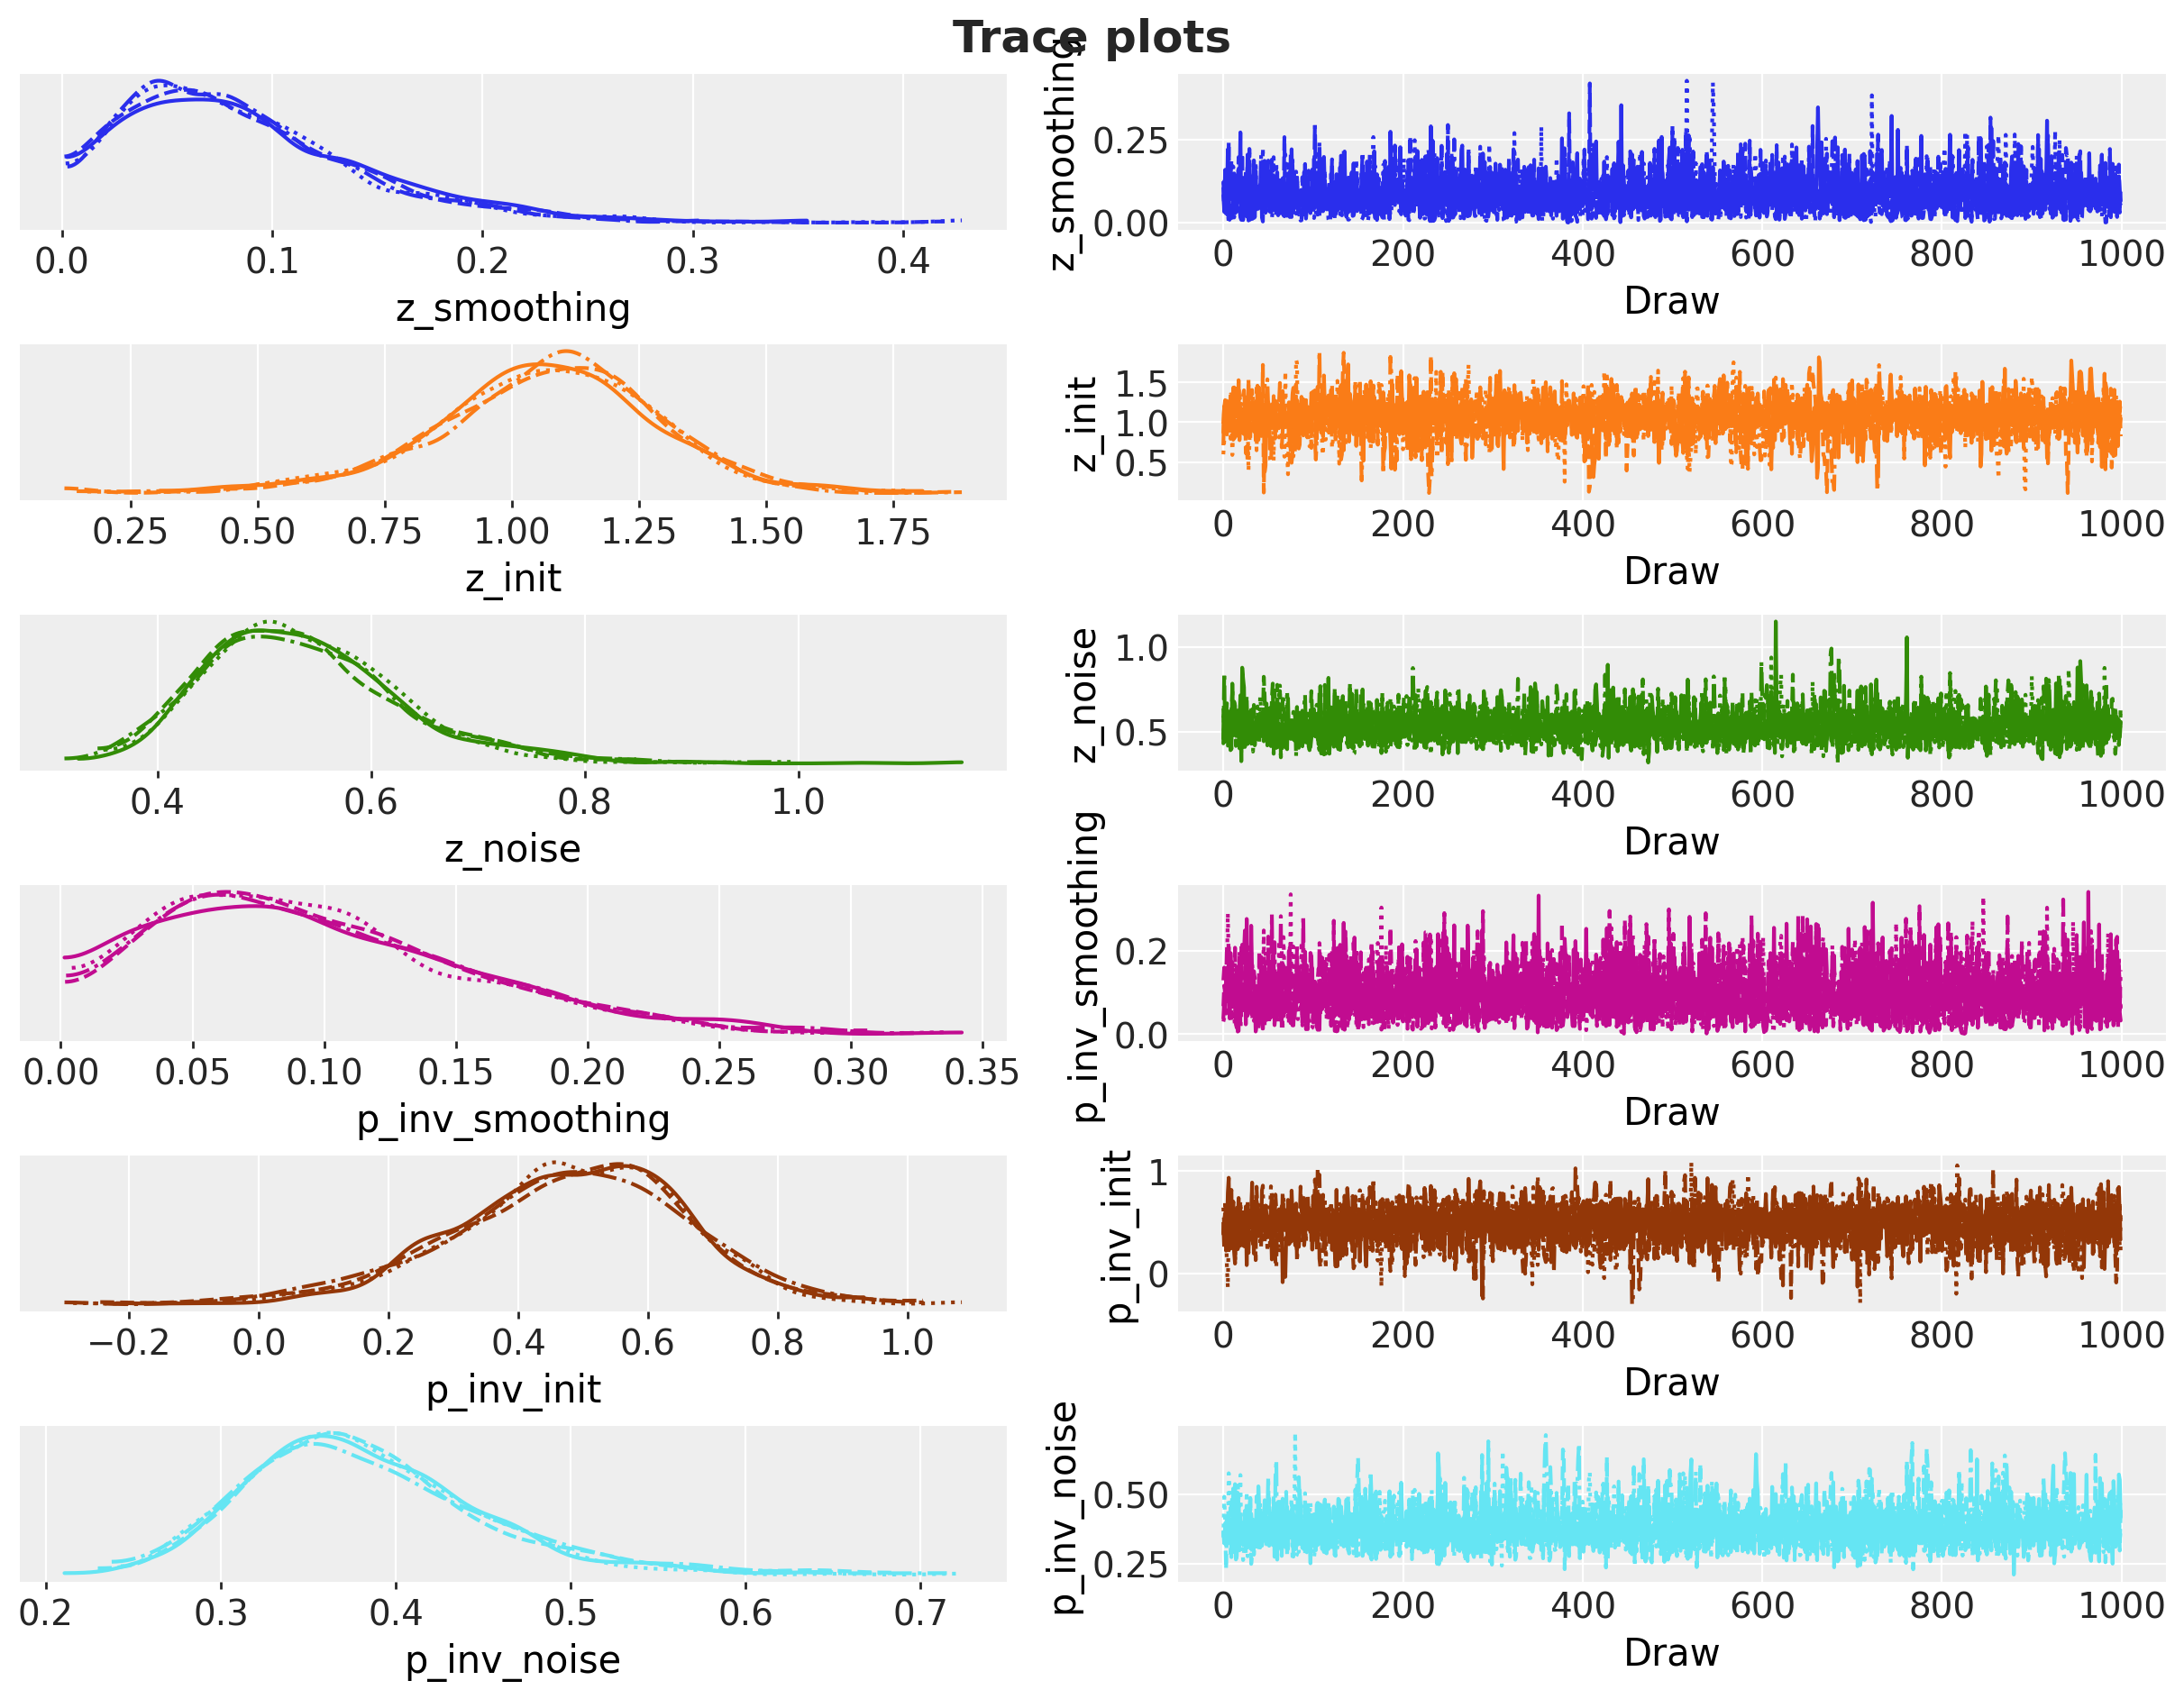

In [9]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    compact=True,
    figure_kwargs={"figsize": (12, 9)},
)
pc_trace.viz["figure"].item().suptitle(
    "Trace plots",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## In-sample fit

For the in-sample story we plot the posterior of the deterministic
`"rate"` site: the running Croston fitted rate
$\ell^z_{t-1} \cdot \ell^{1/p}_{t-1}$, the expected demand per period
given the history so far. This is the quantity Croston’s method actually
tracks, and the plot shows it doing exactly what it should: it starts
uncertain and near the prior, then climbs as demands arrive more and
more frequently in the second half of the training window, because
exponential smoothing weights the recent inter-demand intervals most
heavily. Per the bias note in the model section, the level of the fitted
rate should also be read as somewhat optimistic: smoothing the inverse
intervals inflates it relative to the underlying demand frequency, on
top of the recency weighting. This cell also defines the small plotting
helpers (`stacked_draws` and `plot_band_forecast`) shared by the
remaining band plots, so the later plot cells contain only what is
specific to each figure.

A caveat worth spelling out: the tree’s `posterior_predictive` group
(the `"obs"` site) is *not* comparable to the raw series here. Because
`"obs"` carries the masked demand-size likelihood, its draws describe
the size of a demand *given that one occurs*, at every period, so
plotting them against the mostly-zero series would look wildly
miscalibrated while being exactly what the model asserts. The same
reasoning is why the cross-validation below scores only out-of-sample
forecasts (`eval_train=False`).

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

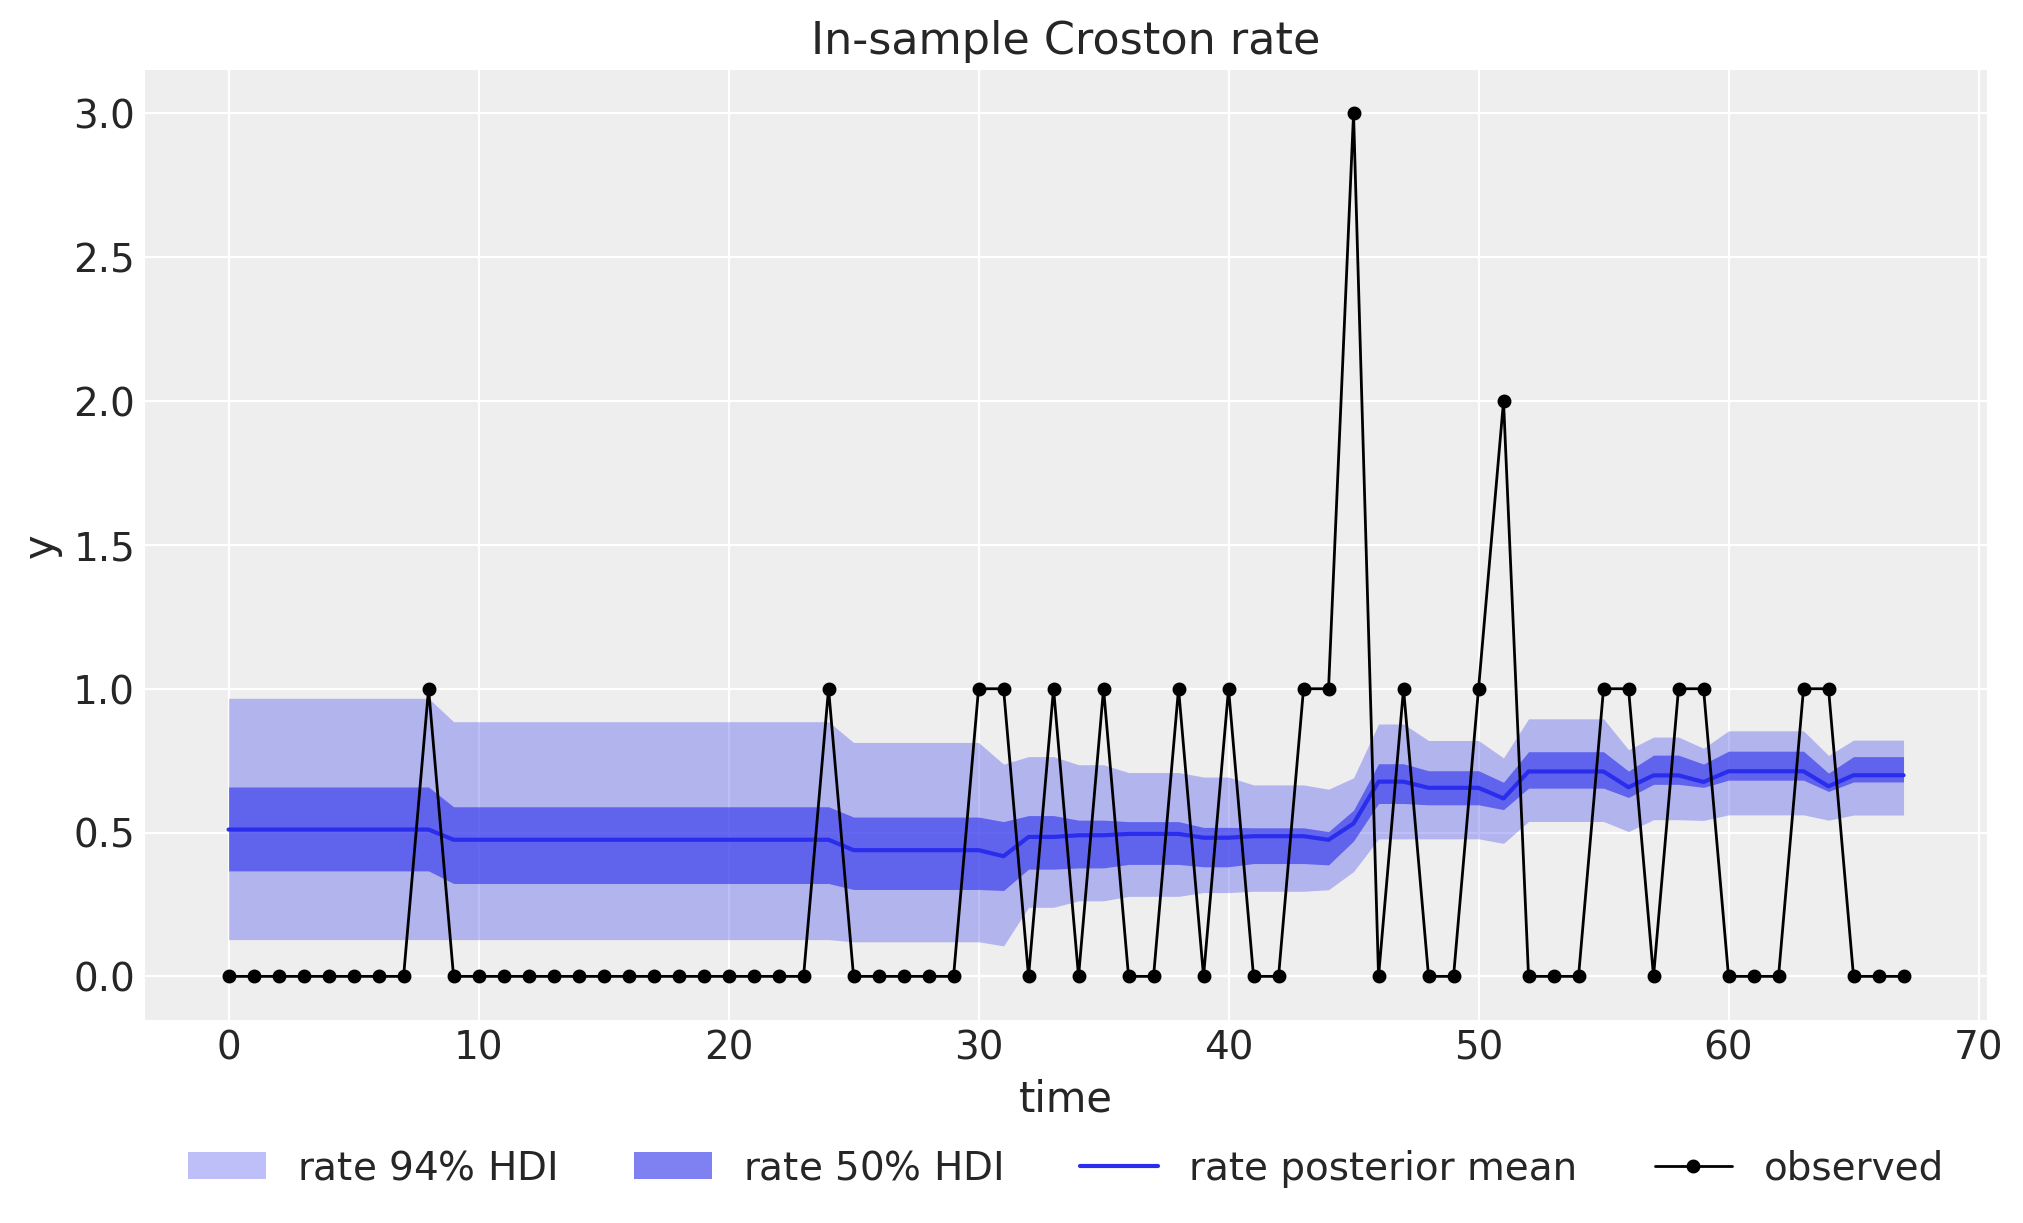

In [10]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter


def stacked_draws(group: xr.DataTree | xr.DataArray, var: str) -> np.ndarray:
    """Stack a tree variable's ``(chain, draw)`` dims into a leading sample axis.

    Parameters
    ----------
    group
        A tree group holding ``var`` with dims ``(chain, draw, time, obs_dim)``
        (typed as the union ``tree[...]`` returns; a group always arrives here).
    var
        Name of the variable to extract.

    Returns
    -------
    np.ndarray
        The draws with shape ``(sample, time, obs_dim)``.
    """
    return (
        group.dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


def plot_band_forecast(
    draws: np.ndarray,
    x: np.ndarray,
    color: str,
    label_prefix: str = "",
    observed: Array | np.ndarray | None = None,
    figsize: tuple[float, float] = (12.0, 6.0),
) -> tuple[Axes, list[Artist]]:
    r"""Plot the posterior mean line and the $50\%$/$94\%$ HDI bands of ``draws``.

    Wraps ``predictions_to_datatree`` and ``az.plot_lm`` with the notebook-wide
    band styling (inner band darker via ``hdi_alphas``) and labels the artists.
    Overlays (observed series, split lines, extra point estimates) and the
    legend are the caller's responsibility.

    Parameters
    ----------
    draws
        Predictive draws with shape ``(sample, time, 1)``.
    x
        Numeric x values of length ``time``.
    color
        Matplotlib color for the bands and the mean line.
    label_prefix
        Prefix for the legend labels, e.g. ``"forecast "``.
    observed
        Optional observed data stored alongside the draws.
    figsize
        Figure size passed to ``plot_lm``.

    Returns
    -------
    tuple[Axes, list[Artist]]
        The axes and the labeled band and mean-line handles for the legend.
    """
    idata = predictions_to_datatree(draws, x, ["y"], observed=observed)
    pc = az.plot_lm(
        idata,
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        point_estimate="mean",
        visuals={
            "ci_band": {"color": color},
            "observed_scatter": False,
            "pe_line": {"color": color, "alpha": 1.0, "width": 1.5},
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": figsize},
    )
    bands = pc.viz["ci_band"]["t"]
    band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
    band_94.set_label(hdi_label(0.94, prefix=label_prefix))
    band_50.set_label(hdi_label(0.5, prefix=label_prefix))
    pe_line = pc.viz["pe_line"]["t"].item()
    pe_line.set_label(f"{label_prefix}posterior mean")
    ax = pc.viz["figure"].item().axes[0]
    return ax, [band_94, band_50, pe_line]


rate_draws = stacked_draws(tree["posterior"], "rate")

ax, handles = plot_band_forecast(
    rate_draws,
    t_train.astype(float),
    "C0",
    label_prefix="rate ",
    observed=train_data,
    figsize=(10.0, 6.0),
)
(obs_line,) = ax.plot(
    t_train, np.asarray(y_train), "o-", color="black", lw=1, ms=4, label="observed"
)
ax.legend(
    handles=[*handles, obs_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)
ax.set(title="In-sample Croston rate", xlabel="time", ylabel="y");

### Why do the HDI bands narrow over time?

Not because the parameter posterior tightens along the axis: the model
is fit once on the whole training window, so the posterior is the same
at every $t$. What is plotted is the posterior of the *deterministic*
filtered rate, and the narrowing is a property of the filter. At $t = 0$
the rate is the product of the two initial levels, whose posteriors are
wide (see the summary table above), so the band starts wide. Every
demand event replaces a fraction $\alpha$ of a level with an observed
value, so after $k$ demand events the initial level retains only a
weight of $(1 - \alpha)^k$: the uncertainty inherited from `z_init` and
`p_inv_init` decays away geometrically, which is why the band stays wide
through the sparse first third of the series and tightens quickly once
demands arrive frequently. At the same time the levels turn into
exponentially weighted averages of *observed* values, which are fixed
constants and, in this series, very regular (almost all demand sizes are
$1$), so even the remaining uncertainty about the smoothing parameters
barely moves them.

Two secondary features confirm this reading. Because the levels are
frozen between demands, the band width is piecewise constant through
runs of zeros: all the narrowing happens at demand events. And the band
briefly *widens* again right after the unusual size-$3$ demand around
$t = 45$, where the level’s jump is $\alpha \, (3 - \ell)$, so
uncertainty about the smoothing parameter translates into uncertainty
about how far the level moved. Finally, keep in mind that this is the
posterior of the mean rate with no observation noise, which is why it
can get so tight; the forecast bands over the test window below are much
wider because they add the component predictive noise
$\text{Normal}(\ell_T, \sigma)$ on top of the parameter uncertainty.

## Forecast

The `predictions` group of the tree already holds the out-of-sample
draws of the `"forecast"` site over the test window: the product of the
two components’ predictive samples. We plot the posterior mean and
median together with the $50\%$ and $94\%$ HDI bands (inner band darker,
outer lighter) against the held-out data, and score the forecast with
the CRPS, a proper scoring rule that compares each observation to the
whole predictive distribution (lower is better).

Two features of the plot deserve attention. First, the forecast is
**flat**: without new observations the levels stay put, so Croston
predicts the same demand rate for every future period. Second, the
predictive distribution is **right-skewed**, so the mean sits visibly
above the median; this asymmetry is information the Bayesian treatment
gives us for free, where the classical implementations wrap a symmetric
interval around a point forecast. The Normal component likelihoods do
let a few draws go slightly negative (the same pragmatic choice as the
blog post); truncated or log-normal component models are a natural
exercise on top of this notebook.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

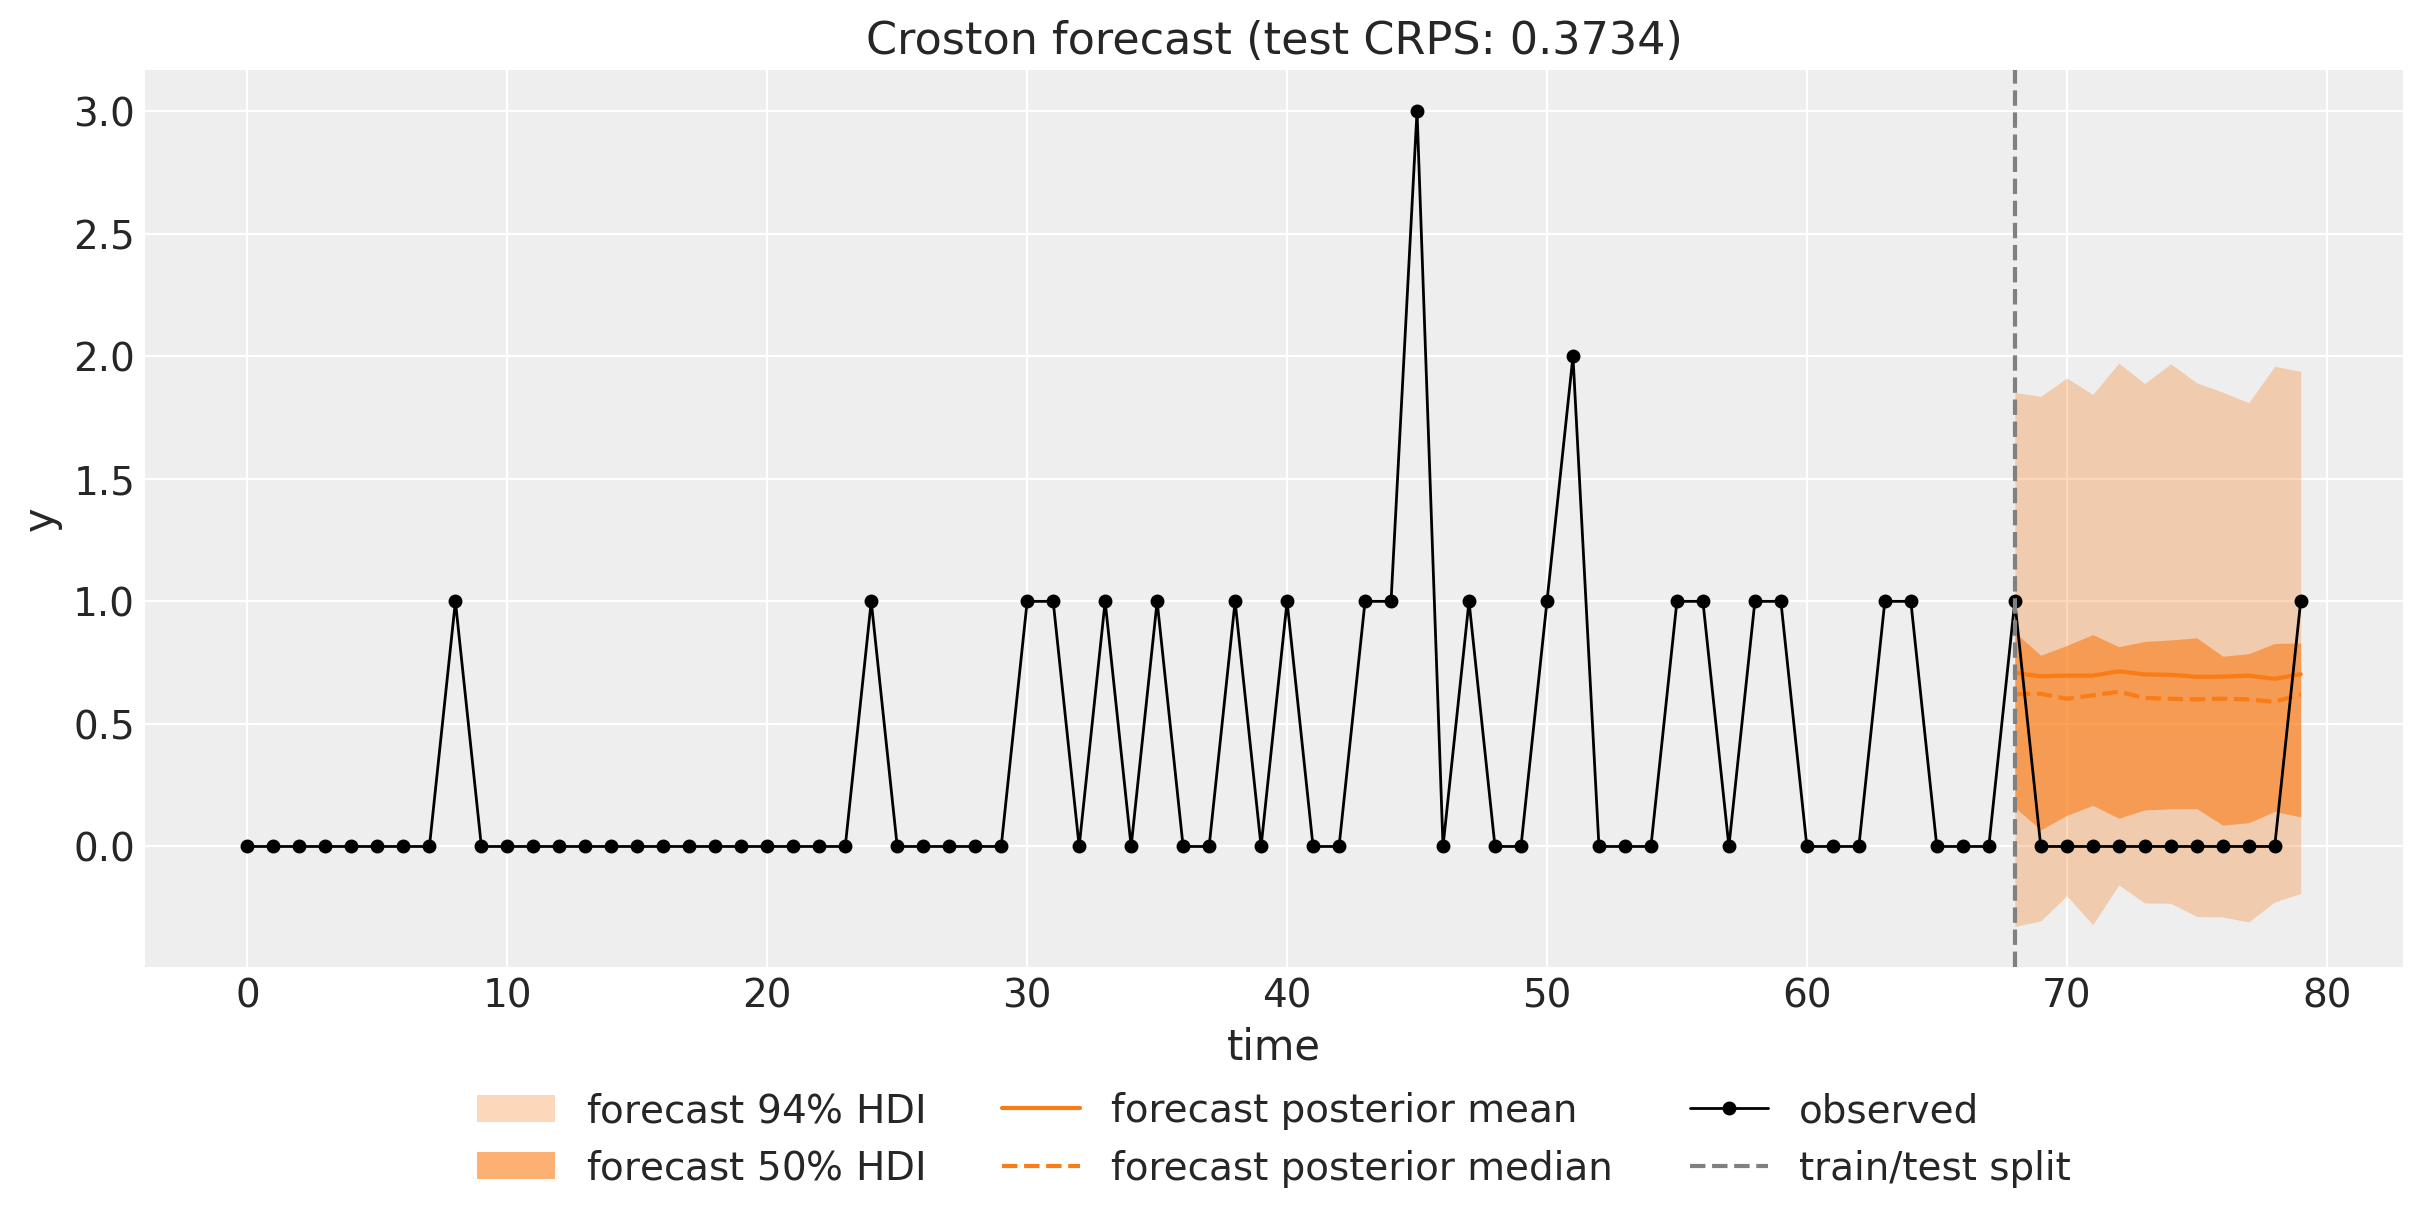

In [11]:
forecast_pp = stacked_draws(tree["predictions"], "obs")
crps_test = eval_crps(forecast_pp, test_data)

ax, handles = plot_band_forecast(
    forecast_pp, t_test.astype(float), "C1", label_prefix="forecast ", observed=test_data
)
(median_line,) = ax.plot(
    t_test,
    np.median(forecast_pp[..., 0], axis=0),
    color="C1",
    ls="--",
    lw=1.5,
    label="forecast posterior median",
)
(obs_line,) = ax.plot(t, np.asarray(y), "o-", color="black", lw=1, ms=4, label="observed")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, median_line, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Croston forecast (test CRPS: {crps_test:.4f})",
    xlabel="time",
    ylabel="y",
);

### The Syntetos-Boylan correction

We can quantify the inversion bias directly from the posterior. Syntetos
and Boylan derived their correction for the classical point estimator:
multiply the Croston rate by $(1 - \alpha_p/2)$, where $\alpha_p$ is the
interval smoothing parameter. Applying the same factor *per posterior
draw* of `p_inv_smoothing` gives an approximately de-biased version of
our forecast (approximate, because the factor was derived for the
classical estimator, not for this Bayesian variant). The cell below
compares the posterior mean forecast rate, its SBA-corrected version,
and the train-window mean demand per period. With the low posterior
smoothing values the correction is small, and the corrected rate remains
well above the marginal mean: the remaining gap combines the recency
weighting (the end of the training window is genuinely demand-dense)
with the residual Jensen bias of smoothing inverse intervals, which the
first-order SBA factor does not fully remove.

In [12]:
alpha_p = tree["posterior"].dataset["p_inv_smoothing"].stack(sample=("chain", "draw")).to_numpy()
forecast_sba = forecast_pp * (1 - alpha_p[:, None, None] / 2)

print(f"posterior mean forecast rate:        {forecast_pp.mean():.3f}")
print(f"SBA-corrected mean forecast rate:    {forecast_sba.mean():.3f}")
print(f"train-window mean demand per period: {float(jnp.mean(y_train)):.3f}")

posterior mean forecast rate:        0.699
SBA-corrected mean forecast rate:    0.663
train-window mean demand per period: 0.338

### Component forecasts

To see where the combined forecast comes from, we sample the two
component predictives directly with `Predictive`, requesting the
`"z_forecast"` and `"p_inv_forecast"` deterministic sites, and plot them
side by side with a single faceted `plot_lm` call (the package’s
`predictions_to_datatree` lays the draws out so that `plot_lm` facets
one panel per series). The demand-size component predicts the size of
the next demand; the inverse-interval component predicts how much of a
demand event arrives per period. Their product is the forecast above.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

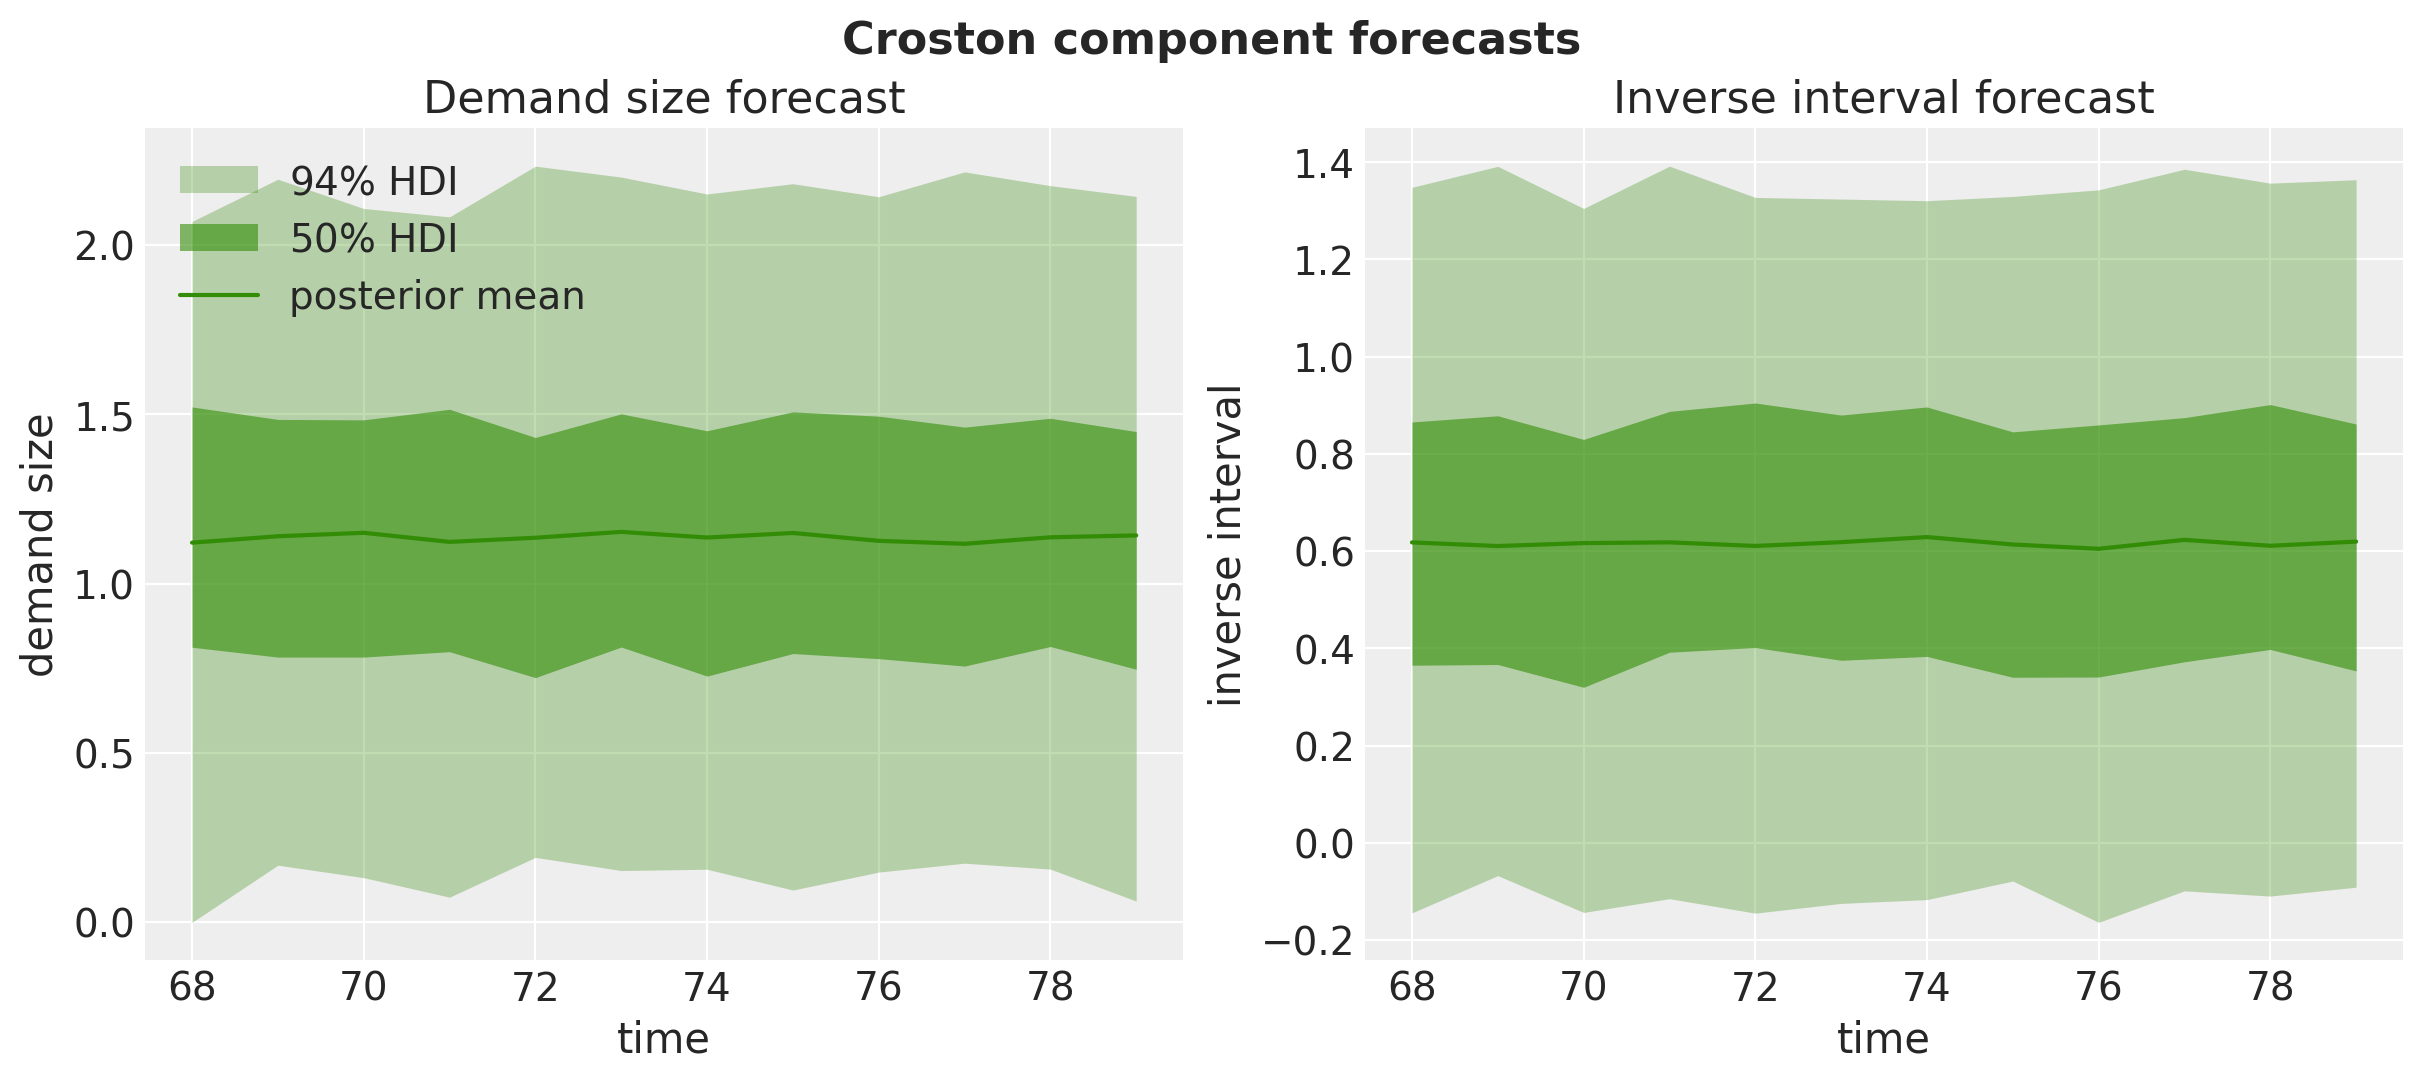

In [13]:
rng_key, rng_subkey = random.split(rng_key)
predictive = Predictive(
    model,
    posterior_samples=dict(fit.samples),
    return_sites=["z_forecast", "p_inv_forecast"],
)
component_draws = predictive(rng_subkey, covariates_full, train_data)
components = np.concatenate(
    [
        np.asarray(component_draws["z_forecast"]),
        np.asarray(component_draws["p_inv_forecast"]),
    ],
    axis=-1,
)

idata_components = predictions_to_datatree(
    components, t_test.astype(float), ["demand size", "inverse interval"]
)
pc = az.plot_lm(
    idata_components,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C2"},
        "observed_scatter": False,
        "pe_line": {"color": "C2", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 5), "sharex": True},
)
axes = pc.viz["plot"]["t"]
axes.sel(series="demand size").item().set(
    title="Demand size forecast", xlabel="time", ylabel="demand size"
)
axes.sel(series="inverse interval").item().set(
    title="Inverse interval forecast", xlabel="time", ylabel="inverse interval"
)
bands = pc.viz["ci_band"]["t"]
band_94 = bands.sel(series="demand size", prob=0.94).item()
band_50 = bands.sel(series="demand size", prob=0.5).item()
band_94.set_label(hdi_label(0.94))
band_50.set_label(hdi_label(0.5))
pe_line = pc.viz["pe_line"]["t"].sel(series="demand size").item()
pe_line.set_label("posterior mean")
axes.sel(series="demand size").item().legend(handles=[band_94, band_50, pe_line], loc="upper left")
fig = pc.viz["figure"].item()
fig.suptitle("Croston component forecasts", fontsize=16, fontweight="bold", y=1.05);

## One-step-ahead cross-validation

A fixed-origin forecast tells us how the model does from one training
window. The blog post’s more interesting experiment is a
**rolling-origin, one-step-ahead** evaluation: refit the model on an
expanding training window and forecast a single step, repeatedly, across
the whole test span.
[`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html)
runs this loop for us with `test_window=1` and `stride=1`, refitting the
NUTS sampler on each fold through `HMCForecaster`, the OOP counterpart
of `fit_mcmc` that `backtest` constructs per fold. With
`min_train_window=n_train` the folds tile the test span exactly, one
fold per held-out period, and `keep_predictions=True` retains each
fold’s forecast samples so we can assemble and plot them. Alongside the
CRPS we track the empirical coverage of the central $50\%$ and $94\%$
intervals as per-fold indicators (with a single test point per fold,
each is $0$ or $1$; we aggregate them across folds below).

In [14]:
metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
results = backtest(
    rng_subkey,
    data_full,
    data_full,  # the series doubles as the covariates, sliced per fold by backtest
    lambda: model,
    forecaster_fn=HMCForecaster,
    metrics=metrics,
    test_window=1,  # one-step-ahead forecasts
    stride=1,  # one fold per held-out period
    min_train_window=n_train,  # folds tile the test span exactly
    num_samples=2_000,
    eval_train=False,  # in-sample "obs" scoring is not meaningful here (see above)
    keep_predictions=True,
    forecaster_options={"num_warmup": 1_000, "num_samples": 1_000, "num_chains": 4},
)

split_points = [r.t1 for r in results]
test_crps = [r.metrics["crps"] for r in results]
print(f"folds: {len(results)} (split points: {split_points})")

folds: 12 (split points: [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79])

### One-step-ahead forecasts

Because the folds tile the test span, we can concatenate the per-fold
forecast samples into a single array of one-step-ahead predictive draws
over the test window and plot them in one go.

The plot delivers the punchline of the blog post. Croston’s forecast
**barely moves while zeros accumulate**: the levels only update at
demand events, so appending another zero changes nothing except the
(unmodeled) age of the last demand, and the one-step-ahead bands stay
flat through runs of zeros. Only when a non-zero demand arrives does the
forecast shift, and with the low posterior smoothing parameters even
that shift is small. This unresponsiveness to the *recency* of demand is
Croston’s well-known structural weakness, and it is precisely what the
[TSB method](https://juanitorduz.github.io/tsb_numpyro/) fixes by
smoothing a demand *probability* at every period instead of an interval
at demand events only.

assembled one-step-ahead draws: (2000, 12, 1)

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(

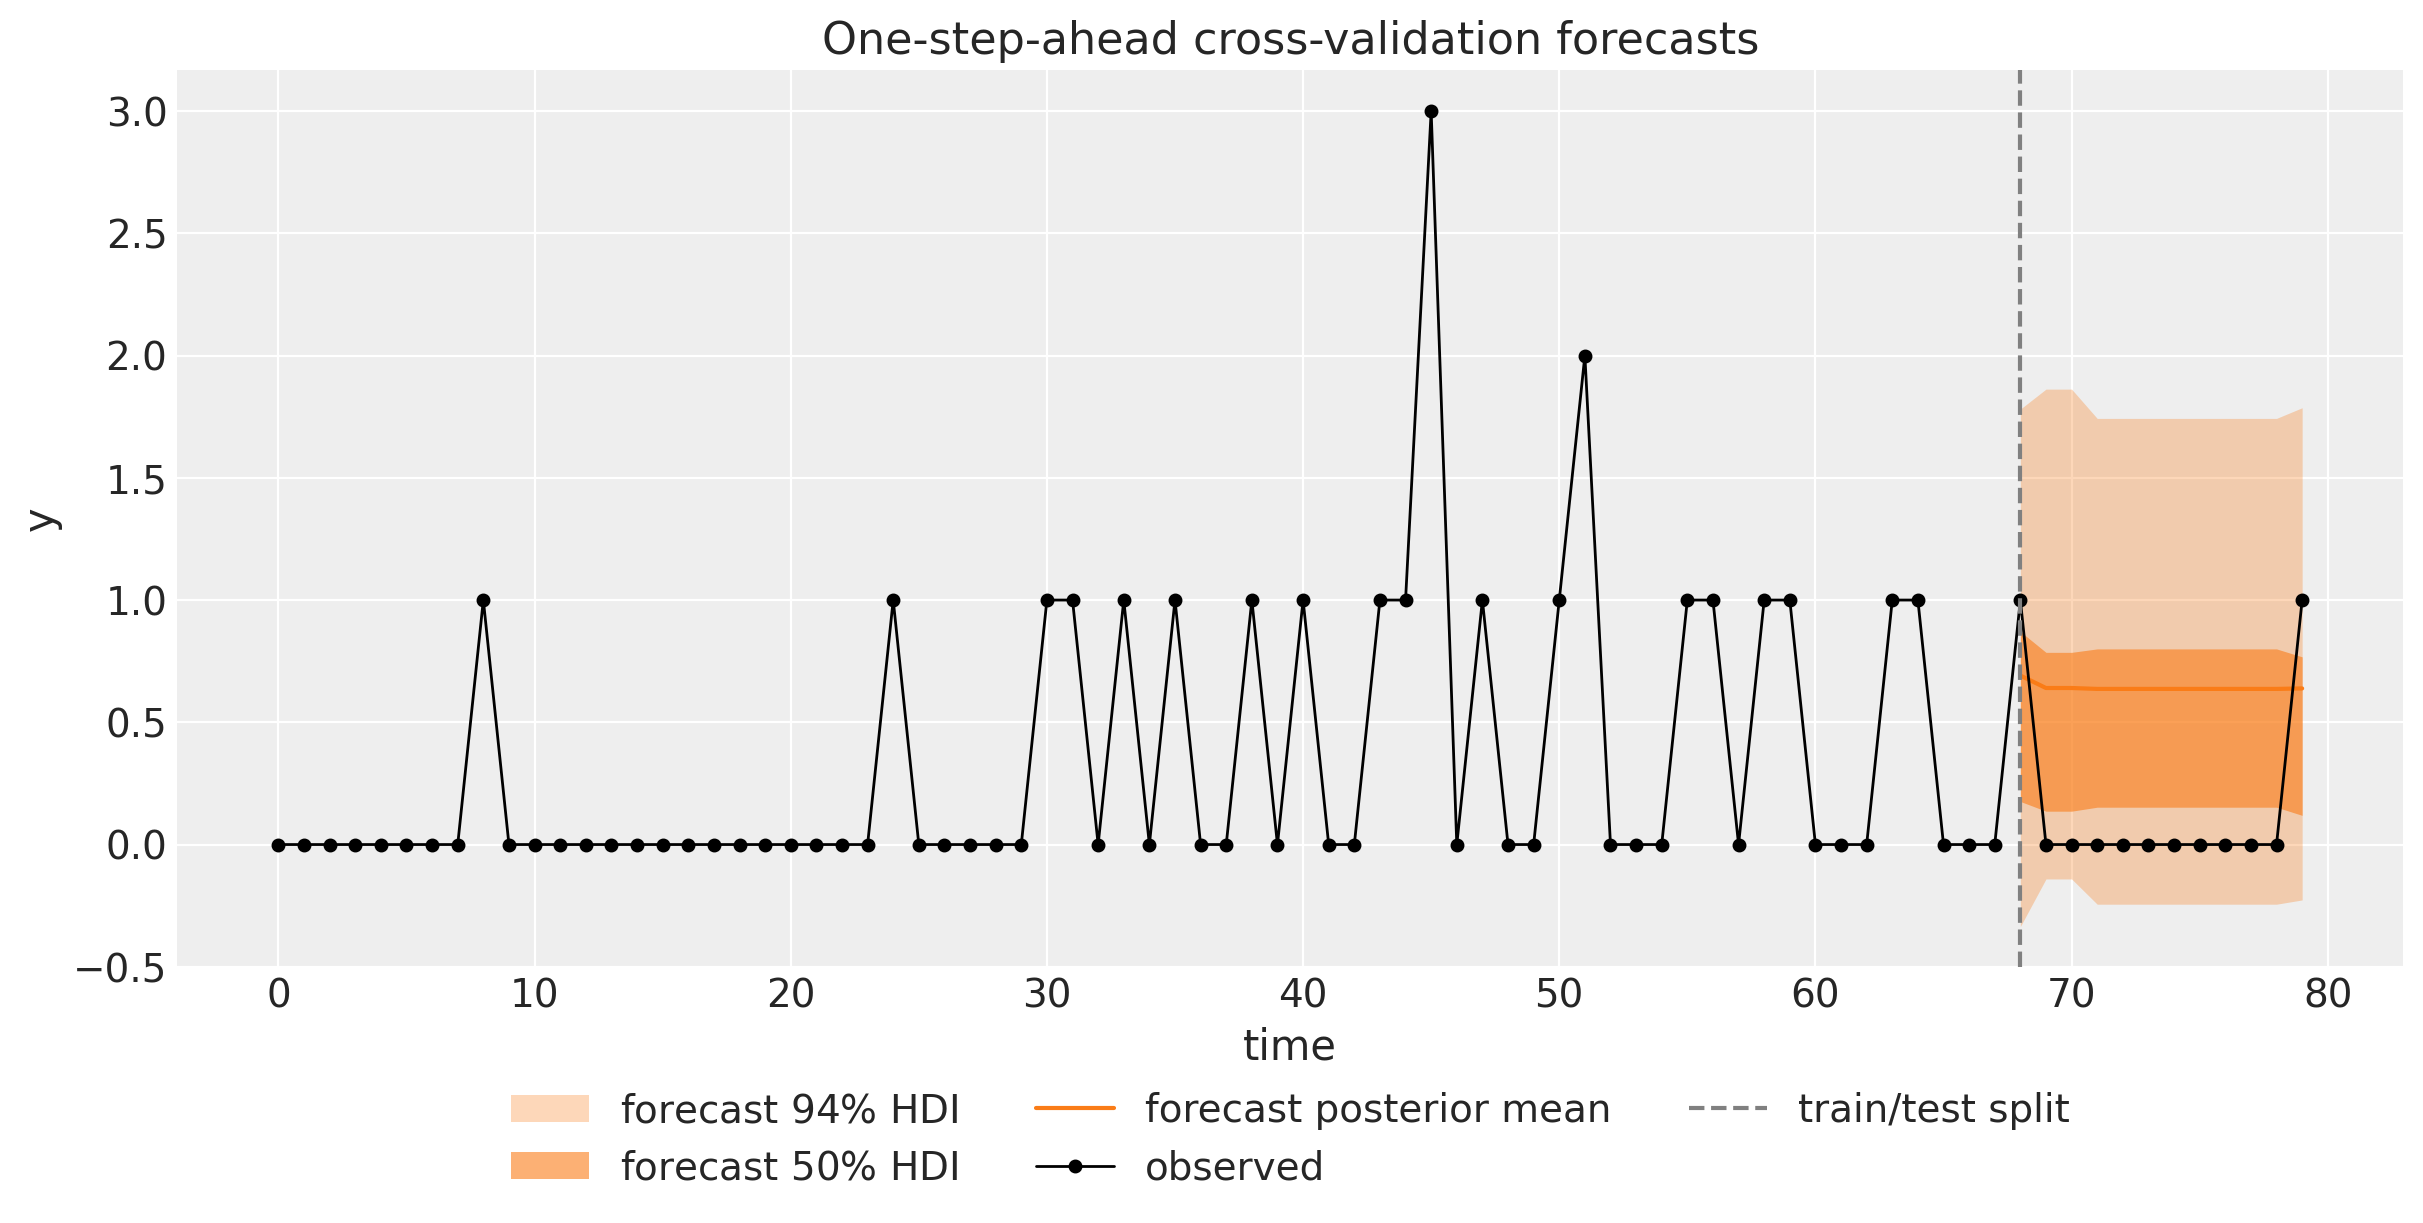

In [15]:
predictions = [r.prediction for r in results if r.prediction is not None]
cv_pred = np.concatenate([np.asarray(pred) for pred in predictions], axis=1)
print(f"assembled one-step-ahead draws: {cv_pred.shape}")

ax, handles = plot_band_forecast(
    cv_pred, t_test.astype(float), "C1", label_prefix="forecast ", observed=test_data
)
(obs_line,) = ax.plot(t, np.asarray(y), "o-", color="black", lw=1, ms=4, label="observed")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="One-step-ahead cross-validation forecasts", xlabel="time", ylabel="y");

### CRPS per fold

The per-fold CRPS makes the same point numerically: because the forecast
barely changes from fold to fold, the score only moves when the
*realization* does, and the plot is essentially two horizontal levels,
one for the zero periods and one for the demand periods. The direction
of the gap is worth a second look: the two demand periods score *better*
than the zeros. After the demand-dense end of the training window the
posterior rate sits closer to $1$ than to $0$, so a size-one demand is
actually the cheaper outcome, while every zero pays the roughly constant
price of a rate forecast that cannot switch itself off between demands.

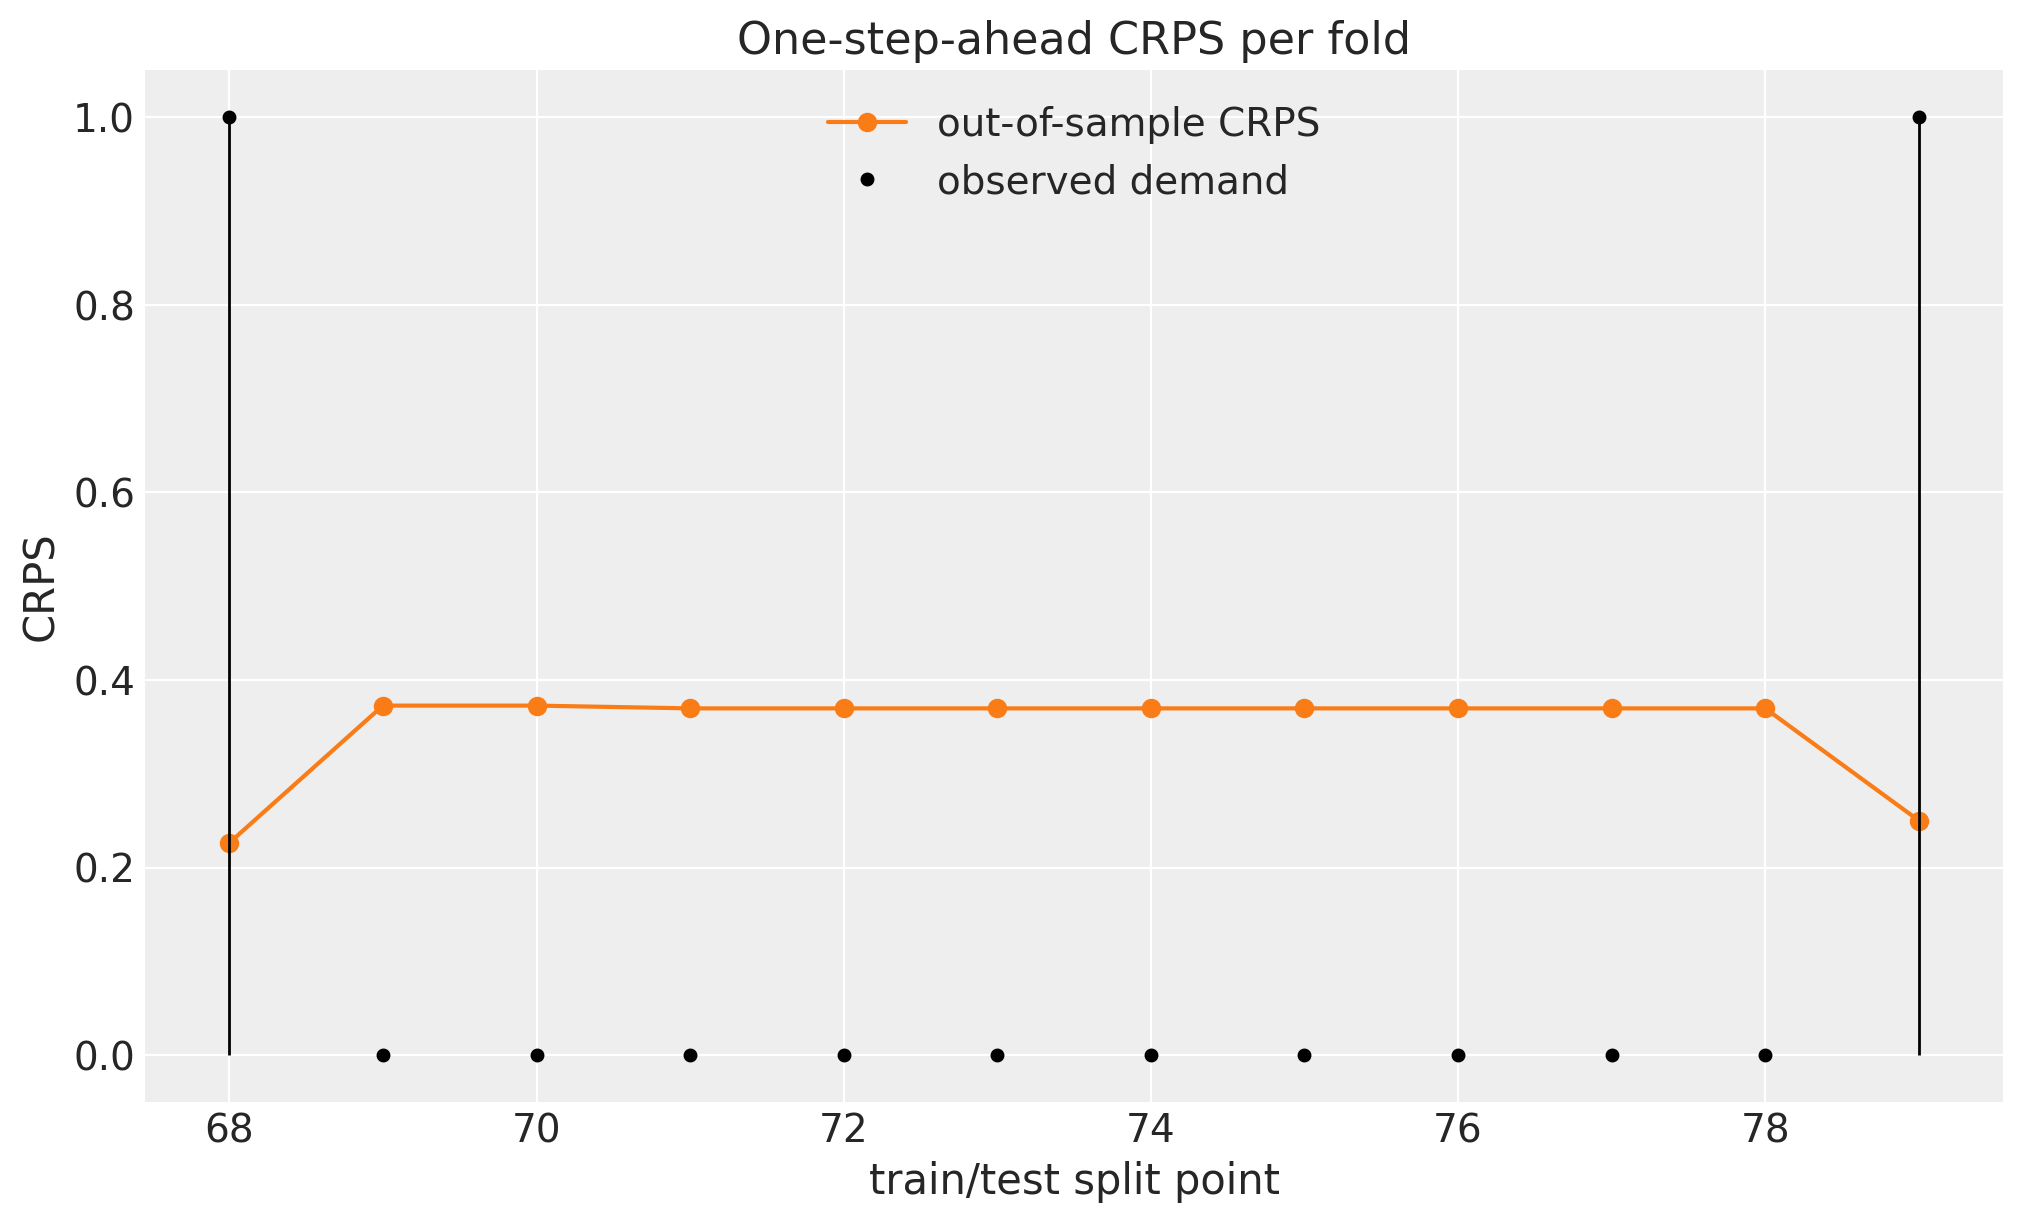

In [16]:
fig, ax = plt.subplots()
ax.plot(split_points, test_crps, "o-", color="C1", label="out-of-sample CRPS")
markerline, stemlines, baseline = ax.stem(t_test, np.asarray(y_test), basefmt=" ")
plt.setp(markerline, color="black", markersize=4, label="observed demand")
plt.setp(stemlines, color="black", linewidth=1)
ax.legend()
ax.set(
    xlabel="train/test split point",
    ylabel="CRPS",
    title="One-step-ahead CRPS per fold",
);

### Calibration

With a single observation per fold, per-fold coverage is a $0/1$
indicator, so instead of the ARMA example’s per-fold coverage plot we
aggregate: the empirical coverage across all folds (equivalently, the
mean of the per-fold indicators) against the nominal levels, computed
directly from the assembled draws with `eval_coverage`. We also compare
the one-step-ahead CRPS with the fixed-origin CRPS from the forecast
section.

One caveat, inherited from the ARMA example but sharper here:
`eval_coverage` measures coverage of the *central quantile interval*,
while the plotted bands are HDIs. For the ARMA example’s near-symmetric
predictive the two nearly coincide; for the right-skewed predictive here
they genuinely differ, so these numbers check the calibration of central
intervals rather than literally of the bands shown above.

In [17]:
cv_crps = eval_crps(cv_pred, test_data)
cov_50 = eval_coverage(cv_pred, test_data, alpha=0.5)
cov_94 = eval_coverage(cv_pred, test_data, alpha=0.94)

print(f"one-step-ahead CRPS over the test span: {cv_crps:.4f}")
print(f"fixed-origin CRPS over the test span:   {crps_test:.4f}")
print(f"empirical 50% coverage: {cov_50:.2f}  (nominal 0.50)")
print(f"empirical 94% coverage: {cov_94:.2f}  (nominal 0.94)")

one-step-ahead CRPS over the test span: 0.3484
fixed-origin CRPS over the test span:   0.3734
empirical 50% coverage: 0.08  (nominal 0.50)
empirical 94% coverage: 1.00  (nominal 0.94)

The numbers complete the picture, and they are instructive rather than
flattering. Refitting at every step buys almost nothing over forecasting
the whole span from a fixed origin, which is the punchline again in
metric form: the new observations are mostly zeros, and zeros do not
move a Croston forecast. The coverage is badly off nominal in an
asymmetric way: the central $50\%$ interval of the rate forecast lies
strictly above zero, so on a test span dominated by zeros it almost
never covers, while the wide $94\%$ interval covers everything. This is
not an inference failure but a structural mismatch: Croston’s predictive
describes the *demand rate per period*, not the count distribution of
the individual periods, so per-period interval coverage on a zero-heavy
series is poor by construction. A predictive that actually covers the
observed counts needs an explicit per-period model of demand occurrence,
which is precisely what the TSB method adds.

## References

- Orduz, J. [*Croston’s Method for Intermittent Time Series Forecasting
  in NumPyro*](https://juanitorduz.github.io/croston_numpyro/). The blog
  post this notebook ports.
- Orduz, J. [*TSB Method for Intermittent Time Series Forecasting in
  NumPyro*](https://juanitorduz.github.io/tsb_numpyro/). The follow-up
  method that addresses Croston’s unresponsiveness to demand recency.
- Orduz, J. [*Notes on Exponential Smoothing with
  NumPyro*](https://juanitorduz.github.io/exponential_smoothing_numpyro/).
  The predecessor post whose level model this notebook reuses.
- Croston, J. D. (1972). *Forecasting and stock control for intermittent
  demands*. Operational Research Quarterly, 23(3), 289-303.
- Syntetos, A. A., & Boylan, J. E. (2005). *The accuracy of intermittent
  demand estimates*. International Journal of Forecasting, 21(2),
  303-314. The bias analysis behind the $(1 - \alpha/2)$ correction
  quantified above.
- Morgan, P. [*Croston’s
  Method*](https://www.pmorgan.com.au/tutorials/crostons-method/). A
  succinct tutorial on the classical method.
- statsforecast documentation:
  [`CrostonOptimized`](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#crostonoptimized),
  the classical baseline the blog post compares against.
- The [exponential smoothing
  example](https://juanitorduz.github.io/numpyro_forecast/examples/exponential_smoothing_state_space.html)
  in this documentation, which uses the same custom model-body pattern
  for the damped Holt-Winters state space model.
- The [ARMA
  example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html)
  in this documentation, which introduces the series-as-covariates
  pattern and the expanding-window `backtest` workflow.